In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import umap
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.metrics import balanced_accuracy_score

In [88]:
# ============================================================
# LOAD ALL FILES FROM BOTH FOLDERS
# ============================================================
import pandas as pd
from pathlib import Path

def load_folder(folder_path):
    records = []
    for f in Path(folder_path).glob('*.xlsx'):
        parts = f.stem.split('_')
        pathogen  = parts[0]
        condition = parts[1]
        srr_id    = parts[2]
        prjna_id  = parts[3]
        cell_type = '_'.join(parts[4:])
        records.append({
            'filename': f,
            'pathogen': pathogen,
            'condition': condition,
            'srr_id': srr_id,
            'study': prjna_id,
            'cell_type': cell_type
        })
    return pd.DataFrame(records)

# load both folders
hsv1_meta_raw = load_folder(r'C:\Users\mariaplumber\Downloads\HHV11')
hcmv_meta_raw = load_folder(r'C:\Users\mariaplumber\Downloads\HCMV5')
aspergillus_meta_raw = load_folder(r'C:\Users\mariaplumber\Downloads\Asper')
candida_meta_raw = load_folder(r'C:\Users\mariaplumber\Downloads\Cand')
pseudomonas_meta_raw = load_folder(r'C:\Users\mariaplumber\Downloads\Pseu')
mycobacterium_meta_raw = load_folder(r'C:\Users\mariaplumber\Downloads\Myc')
meta_all = pd.concat([hsv1_meta_raw, hcmv_meta_raw, aspergillus_meta_raw, candida_meta_raw, pseudomonas_meta_raw, mycobacterium_meta_raw ], ignore_index=True)
#meta_all = pd.concat([hsv1_meta_raw, hcmv_meta_raw, aspergillus_meta_raw, candida_meta_raw, mycobacterium_meta_raw ], ignore_index=True)
print(f"Total files: {len(meta_all)}")
print(meta_all['pathogen'].value_counts())

Total files: 330
pathogen
Aspergillus    63
HSV1           56
Pseuaer        56
HCMV           52
Candida        52
Myctub         51
Name: count, dtype: int64


In [89]:
# ============================================================
# BUILD COMBINED TPM MATRIX
# ============================================================
print("Loading all Excel files...")
tpm_dict = {}
total = len(meta_all)

for i, (_, row) in enumerate(meta_all.iterrows(), 1):
    print(f"  Loading file {i}/{total}: {row['srr_id']}", end='\r')
    df = pd.read_excel(row['filename'])
    df['target_id'] = df['target_id'].str.split('.').str[0]
    df = df.set_index('target_id')
    tpm_dict[row['srr_id']] = df['tpm']

print(f"\nDone! Loaded {total}/{total} files.")
tpm_combined = pd.DataFrame(tpm_dict)
print(f"Combined TPM matrix: {tpm_combined.shape}")

# align metadata
meta_all = meta_all.set_index('srr_id')
meta_all = meta_all.loc[tpm_combined.columns]

Loading all Excel files...
  Loading file 330/330: SRR92097242
Done! Loaded 330/330 files.
Combined TPM matrix: (207175, 330)


In [90]:
# ============================================================
# STEP 2 — TRANSCRIPT TO GENE CONVERSION
# ============================================================
TX2GENE = r"D:\HHVBiomaker\tx2gene.tsv"

tx2gene = pd.read_csv(TX2GENE, sep="\t")
tx2gene["target_id"] = tx2gene["target_id"].str.split(".").str[0]

print(f"tx2gene mapping: {len(tx2gene)} transcripts")
print(f"Unique genes: {tx2gene['gene_name'].nunique()}")

# check overlap
overlap = set(tpm_combined.index) & set(tx2gene["target_id"])
print(f"Mapping rate: {len(overlap)/len(tpm_combined)*100:.1f}%")

def transcripts_to_genes(matrix, tx2gene_df, method="sum"):
    merged = (matrix
              .reset_index()
              .rename(columns={"index": "target_id"})
              .merge(tx2gene_df[["target_id", "gene_name"]],
                     on="target_id", how="inner"))
    merged = merged.drop(columns=["target_id"])
    if method == "sum":
        return merged.groupby("gene_name").sum()

print("Aggregating to gene level (this may take a minute)...")
tpm_gene_combined = transcripts_to_genes(tpm_combined, tx2gene, method="sum")
print(f"Gene-level TPM: {tpm_gene_combined.shape}")

tx2gene mapping: 216741 transcripts
Unique genes: 56643
Mapping rate: 82.2%
Aggregating to gene level (this may take a minute)...
Gene-level TPM: (35300, 330)


In [91]:
# ============================================================
# STEP 4 — LOAD ALL ROBUST GENE LISTS (keeps shared/duplicate genes)
# ============================================================
import os
import pandas as pd

robust_files = {
    'HSV1':          r'C:\Users\mariaplumber\Downloads\HHV1_robust_genes.csv',
    'HCMV':          r'C:\Users\mariaplumber\Downloads\HCMV_robust_genes.csv',
    'Aspergillus':   r'C:\Users\mariaplumber\Downloads\Aspergillus_robust_genes.csv',
    'Candida':       r'C:\Users\mariaplumber\Downloads\Candida_robust_genes.csv',
    'Pseudomonas':   r'C:\Users\mariaplumber\Downloads\Pseu_robust_genes.csv',
    'Mycobacterium': r'C:\Users\mariaplumber\Downloads\Myc_robust_genes.csv',
}

robust_genes = {}            # kept as-is: pathogen -> {gene: direction}
all_robust_gene_set = set()  # kept as-is: unique genes (for matrix subsetting)

all_robust_gene_list = []    # NEW: every occurrence, duplicates preserved
robust_records = []          # NEW: long-format (pathogen, gene, direction)

for pathogen, fpath in robust_files.items():
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)

        robust_genes[pathogen] = dict(zip(df['gene'], df['direction']))
        all_robust_gene_set.update(df['gene'].tolist())

        # keep every row, no collapsing
        all_robust_gene_list.extend(df['gene'].tolist())
        for g, d in zip(df['gene'], df['direction']):
            robust_records.append({'pathogen': pathogen, 'gene': g, 'direction': d})

        print(f"{pathogen}: {len(df)} robust genes loaded")
    else:
        print(f"WARNING: {fpath} not found")

robust_long = pd.DataFrame(robust_records)  # NEW: full long table

print(f"\nTotal robust gene entries (duplicates kept): {len(all_robust_gene_list)}")
print(f"Total unique robust genes across all pathogens: {len(all_robust_gene_set)}")

# how many genes are shared by more than one pathogen
gene_counts = robust_long.groupby('gene')['pathogen'].nunique()
shared_genes = gene_counts[gene_counts > 1]
print(f"Genes robust in >1 pathogen: {len(shared_genes)}")

# ---- overlap with filtered matrix ----
matrix_genes = set(tpm_gene_combined.index)

# unique-gene view
overlap_genes = all_robust_gene_set & matrix_genes
print(f"\nUnique genes found in expression matrix: {len(overlap_genes)}")
print(f"Unique genes missing from matrix: {len(all_robust_gene_set - overlap_genes)}")

# entry-level view (a shared gene counts once per pathogen)
robust_long['in_matrix'] = robust_long['gene'].isin(matrix_genes)
print(f"Robust entries found in matrix: {int(robust_long['in_matrix'].sum())}")
print(f"Robust entries missing from matrix: {int((~robust_long['in_matrix']).sum())}")
print("\nPer-pathogen entries retained in matrix:")
print(robust_long[robust_long['in_matrix']].groupby('pathogen').size())

HSV1: 151 robust genes loaded
HCMV: 292 robust genes loaded
Aspergillus: 77 robust genes loaded
Candida: 47 robust genes loaded
Pseudomonas: 40 robust genes loaded
Mycobacterium: 44 robust genes loaded

Total robust gene entries (duplicates kept): 651
Total unique robust genes across all pathogens: 605
Genes robust in >1 pathogen: 39

Unique genes found in expression matrix: 605
Unique genes missing from matrix: 0
Robust entries found in matrix: 651
Robust entries missing from matrix: 0

Per-pathogen entries retained in matrix:
pathogen
Aspergillus       77
Candida           47
HCMV             292
HSV1             151
Mycobacterium     44
Pseudomonas       40
dtype: int64


In [92]:
import numpy as np
# ============================================================
# STEP 5 — BUILD PER-SAMPLE LFC MATRIX
# (infection signal — cell type bias removed)
# ============================================================
print("\nBuilding per-sample LFC matrix...")

lfc_records = []

for study in meta_all['study'].unique():
    study_meta = meta_all[meta_all['study'] == study]
    
    # get mock samples for this study
    mock_samples = study_meta[
        study_meta['condition'] == 'mock'
    ].index.tolist()
    
    # get infected samples for this study
    infected_samples = study_meta[
        study_meta['condition'] != 'mock'
    ].index.tolist()
    
    if len(mock_samples) == 0 or len(infected_samples) == 0:
        print(f"  Skipping {study} — no mock or infected samples")
        continue
    
    # compute mock mean for this study
    mock_expr  = tpm_gene_combined[mock_samples]
    mock_mean  = np.log2(mock_expr + 1).mean(axis=1)
    # compute LFC for each infected sample
    for sample in infected_samples:
        sample_expr = np.log2(
            tpm_gene_combined[sample] + 1
        )
        lfc = sample_expr - mock_mean
        
        # keep only robust genes
        lfc_robust = lfc[lfc.index.isin(overlap_genes)]
        
        record = lfc_robust.to_dict()
        record['sample_id'] = sample
        record['pathogen']  = meta_all.loc[sample, 'pathogen']
        record['condition'] = meta_all.loc[sample, 'condition']
        record['study']     = meta_all.loc[sample, 'study']
        record['cell_type'] = meta_all.loc[sample, 'cell_type']
        lfc_records.append(record)

lfc_df = pd.DataFrame(lfc_records)
lfc_df = lfc_df.set_index('sample_id')

meta_cols = ['pathogen', 'condition', 'study', 'cell_type']
gene_cols  = [c for c in lfc_df.columns if c not in meta_cols]

print(f"LFC matrix: {lfc_df.shape[0]} samples x {len(gene_cols)} genes")
print(f"\nSample distribution:")
print(lfc_df['pathogen'].value_counts())
# save
lfc_df.to_csv(
    r'C:\Users\mariaplumber\Downloads\combined_lfc_matrix.tsv',
    sep="\t"
)
print("\nLFC matrix saved!")
    


Building per-sample LFC matrix...
LFC matrix: 177 samples x 605 genes

Sample distribution:
pathogen
Aspergillus    35
HSV1           34
Pseuaer        29
Candida        28
HCMV           26
Myctub         25
Name: count, dtype: int64

LFC matrix saved!


In [93]:
# ============================================================
# VERIFY LFC MATRIX
# ============================================================
lfc_df = pd.read_csv(
    r'C:\Users\mariaplumber\Downloads\combined_lfc_matrix.tsv',
    sep="\t", index_col=0
)

meta_cols = ['pathogen', 'condition', 'study', 'cell_type']
gene_cols = [c for c in lfc_df.columns if c not in meta_cols]

print(f"LFC matrix shape: {lfc_df.shape}")
print(f"Samples: {lfc_df.shape[0]}")
print(f"Genes:   {len(gene_cols)}")

print(f"\nSample distribution:")
print(lfc_df['pathogen'].value_counts())

print(f"\nCell type distribution:")
print(lfc_df['cell_type'].value_counts())

print(f"\nAny NaN values: {lfc_df[gene_cols].isna().sum().sum()}")

print(f"\nLFC value range:")
print(f"  Min:  {lfc_df[gene_cols].min().min():.3f}")
print(f"  Max:  {lfc_df[gene_cols].max().max():.3f}")
print(f"  Mean: {lfc_df[gene_cols].mean().mean():.3f}")

print(f"\nSample of data:")
print(lfc_df[meta_cols + gene_cols[:3]].head())

LFC matrix shape: (177, 609)
Samples: 177
Genes:   605

Sample distribution:
pathogen
Aspergillus    35
HSV1           34
Pseuaer        29
Candida        28
HCMV           26
Myctub         25
Name: count, dtype: int64

Cell type distribution:
cell_type
THP1                           22
Monocyte-derived-Macrophage    21
ARPE19                         14
Dendritic                      10
Leukocytes                      9
A549                            9
HAP1                            8
HFF1                            8
MRC5                            8
Epithelial                      7
NPCs                            6
HBE                             6
Calu3                           6
OKF6                            6
OralSquamousCellCarcinoma       6
Neutrophils                     6
HLTE                            5
Keratinocyte                    4
nasopharyngealorganoids         3
sc-islets                       3
stemmacrophage                  3
HCT116                         

In [94]:
# ============================================================
# ADD MOCK SAMPLES TO LFC MATRIX
# Mock LFC = expression - its own mean ≈ 0 with noise
# ============================================================

mock_records = []

for study in meta_all['study'].unique():
    study_meta = meta_all[meta_all['study'] == study]
    
    mock_samples = study_meta[
        study_meta['condition'] == 'mock'
    ].index.tolist()
    
    if len(mock_samples) == 0:
        continue
    
    # compute mock mean for this study
    mock_expr = tpm_gene_combined.loc[
        list(overlap_genes), mock_samples
    ]
    mock_mean = np.log2(mock_expr + 1).mean(axis=1)
    
    # each mock sample's LFC vs study mock mean
    for sample in mock_samples:
        sample_expr = np.log2(
            tpm_gene_combined.loc[list(overlap_genes), sample] + 1
        )
        lfc = sample_expr - mock_mean
        
        record = lfc.to_dict()
        record['sample_id'] = sample
        record['pathogen']  = 'Mock'
        record['condition'] = 'mock'
        record['study']     = study
        record['cell_type'] = meta_all.loc[sample, 'cell_type']
        mock_records.append(record)

mock_lfc_df = pd.DataFrame(mock_records).set_index('sample_id')
print(f"Mock samples added: {len(mock_lfc_df)}")

# combine infected + mock
lfc_df_with_mock = pd.concat([lfc_df, mock_lfc_df])
print(f"Combined matrix with Mock: {lfc_df_with_mock.shape}")
print(f"\nFull distribution:")
print(lfc_df_with_mock['pathogen'].value_counts())

Mock samples added: 153
Combined matrix with Mock: (330, 609)

Full distribution:
pathogen
Mock           153
Aspergillus     35
HSV1            34
Pseuaer         29
Candida         28
HCMV            26
Myctub          25
Name: count, dtype: int64


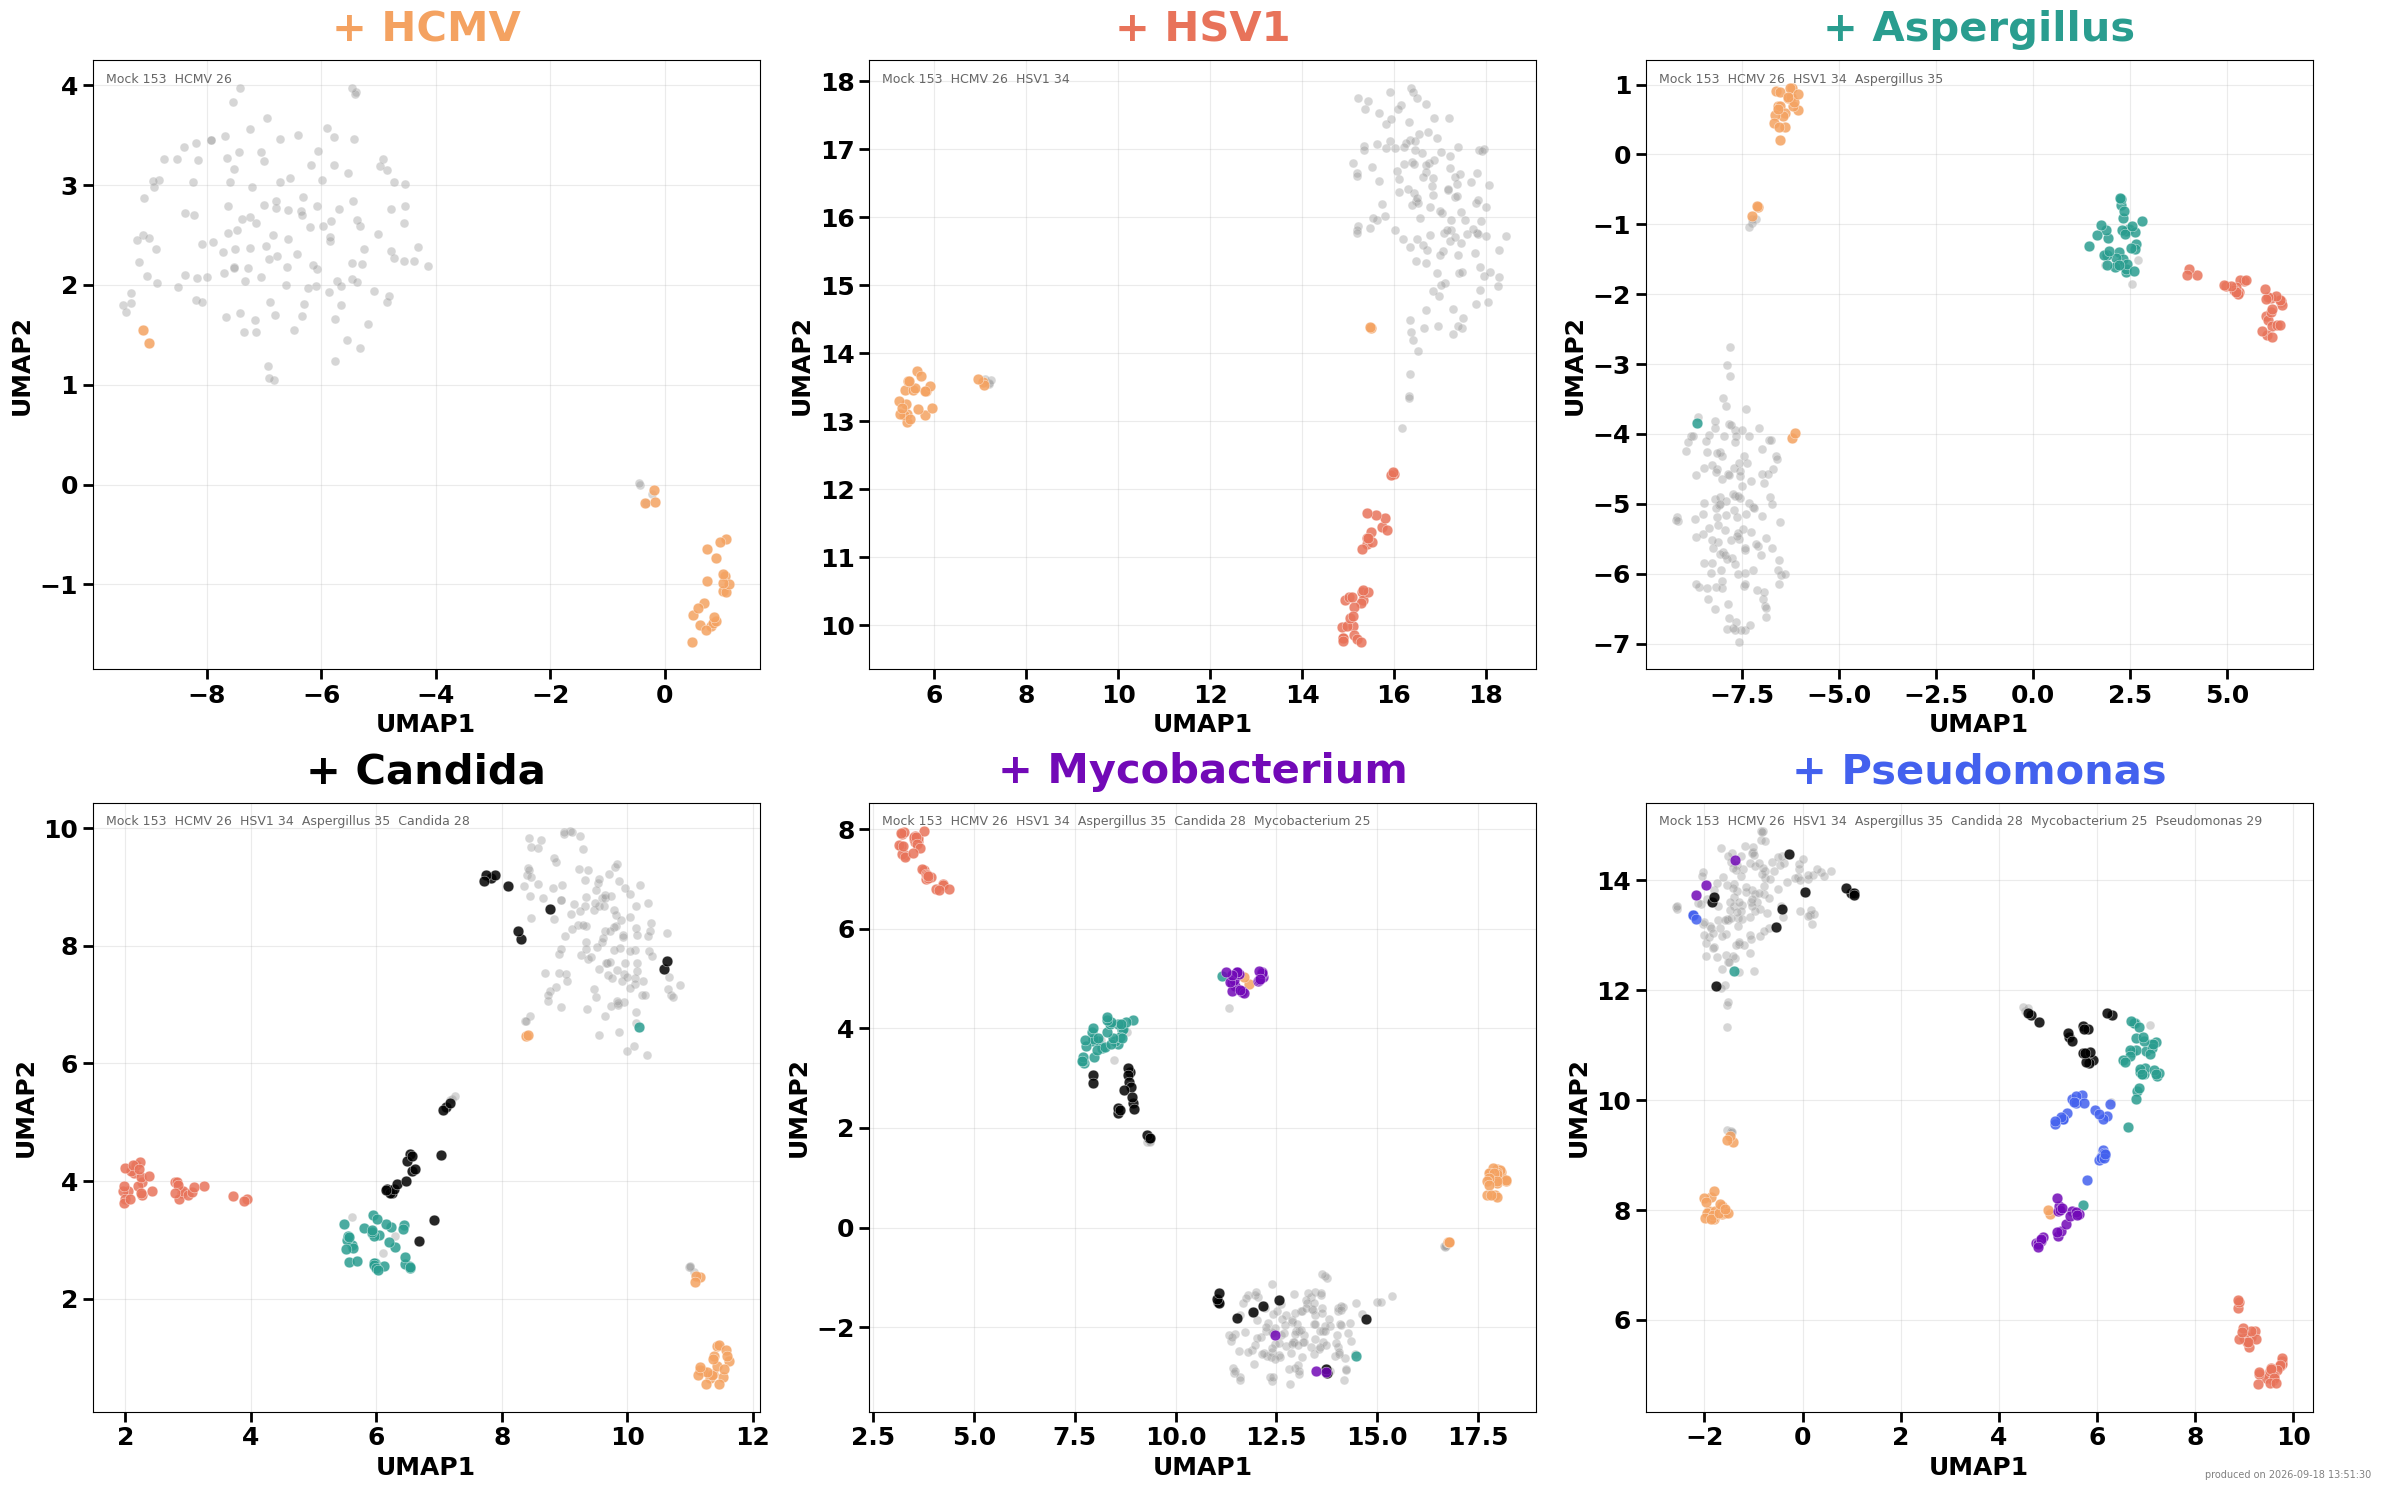

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import umap

# ============================================================
# INCREMENTAL UMAP — independent embedding per panel
# ============================================================
pathogen_order = ['HCMV', 'HSV1', 'Aspergillus', 'Candida',
                  'Mycobacterium', 'Pseudomonas']

pathogen_colors = {
    'HSV1':          '#E8735A',
    'HCMV':          '#F4A261',
    'Aspergillus':   '#2A9D8F',
    'Candida':       '#000000',
    'Pseudomonas':   '#4361EE',
    'Mycobacterium': '#7209B7',
    'Mock':          '#999999',
}

labels = lfc_df_with_mock['pathogen'].replace(
    {'Myctub': 'Mycobacterium', 'Pseuaer': 'Pseudomonas'}
)
available = set(labels.unique())
missing = [p for p in pathogen_order if p not in available]
if missing:
    raise ValueError(f"not found: {missing} — available: {sorted(available)}")

fig, axes = plt.subplots(2, 3, figsize=(24, 15))


for i, ax in enumerate(axes.ravel(), start=1):
    shown = pathogen_order[:i]
    keep  = labels.isin(shown + ['Mock'])
    sub   = lfc_df_with_mock[keep]
    sub_labels = labels[keep]

    X = StandardScaler().fit_transform(sub[gene_cols].fillna(0).values)

    n_nb = min(30, max(2, len(sub) - 1))
    emb = umap.UMAP(n_neighbors=n_nb, min_dist=0.1,
                    metric='cosine', random_state=42).fit_transform(X)

    e = pd.DataFrame(emb, index=sub.index, columns=['UMAP1', 'UMAP2'])
    e['label'] = sub_labels.values

    for p in ['Mock'] + shown:
        grp = e[e['label'] == p]
        ax.scatter(grp['UMAP1'], grp['UMAP2'],
                   c=pathogen_colors.get(p, '#999999'),
                   s=40 if p == 'Mock' else 60,
                   alpha=0.4 if p == 'Mock' else 0.85,
                   edgecolors='white', linewidths=0.3,
                   zorder=1 if p == 'Mock' else 3)

    ax.set_title(f'+ {shown[-1]}',
                 fontsize=30, fontweight='bold', pad=14,
                 color=pathogen_colors.get(shown[-1], '#333333'))
    ax.set_xlabel('UMAP1', fontsize=18, fontweight='bold')
    ax.set_ylabel('UMAP2', fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18, width=2, length=7)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
    ax.grid(True, alpha=0.25)

    counts = '  '.join(f"{p} {(e['label'] == p).sum()}"
                       for p in ['Mock'] + shown)
    ax.text(0.02, 0.98, counts, transform=ax.transAxes,
            fontsize=9, color='#666666', va='top')

fig.text(0.99, 0.01, f'produced on {datetime.now():%Y-%m-%d %H:%M:%S}',
         ha='right', va='bottom', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig(r'C:\Users\mariaplumber\Downloads\UMAP_incremental_6panel_refit.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [96]:
from sklearn.preprocessing import StandardScaler
import umap
# rerun UMAP with new parameters from scratch
X        = lfc_df_with_mock[gene_cols].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer  = umap.UMAP(
    n_neighbors  = 30,
    min_dist     = 0.1,
    metric       = 'cosine',
    random_state = 42
)
umap_res = reducer.fit_transform(X_scaled)

# rebuild umap_df from scratch — don't join on existing
umap_df = pd.DataFrame(
    umap_res,
    index   = lfc_df_with_mock.index,
    columns = ['UMAP1', 'UMAP2']
)

# add metadata directly from lfc_df_with_mock
umap_df['pathogen']       = lfc_df_with_mock['pathogen'].values
umap_df['condition']      = lfc_df_with_mock['condition'].values
umap_df['study']          = lfc_df_with_mock['study'].values
umap_df['cell_type']      = lfc_df_with_mock['cell_type'].values
umap_df['pathogen_clean'] = umap_df['pathogen'].replace(
    {'Myctub': 'Mycobacterium', 'Pseuaer': 'Pseudomonas'}
)

# add pathogen class
class_map = {
    'HSV1':          'Virus',
    'HCMV':          'Virus',
    'Aspergillus':   'Fungus',
    'Candida':       'Fungus',
    'Pseudomonas':   'Bacterium',
    'Mycobacterium': 'Bacterium',
    'Mock':          'Mock'
}
umap_df['pathogen_class'] = umap_df['pathogen_clean'].map(class_map)

print("UMAP done!")
print(umap_df['pathogen_clean'].value_counts())

UMAP done!
pathogen_clean
Mock             153
Aspergillus       35
HSV1              34
Pseudomonas       29
Candida           28
HCMV              26
Mycobacterium     25
Name: count, dtype: int64


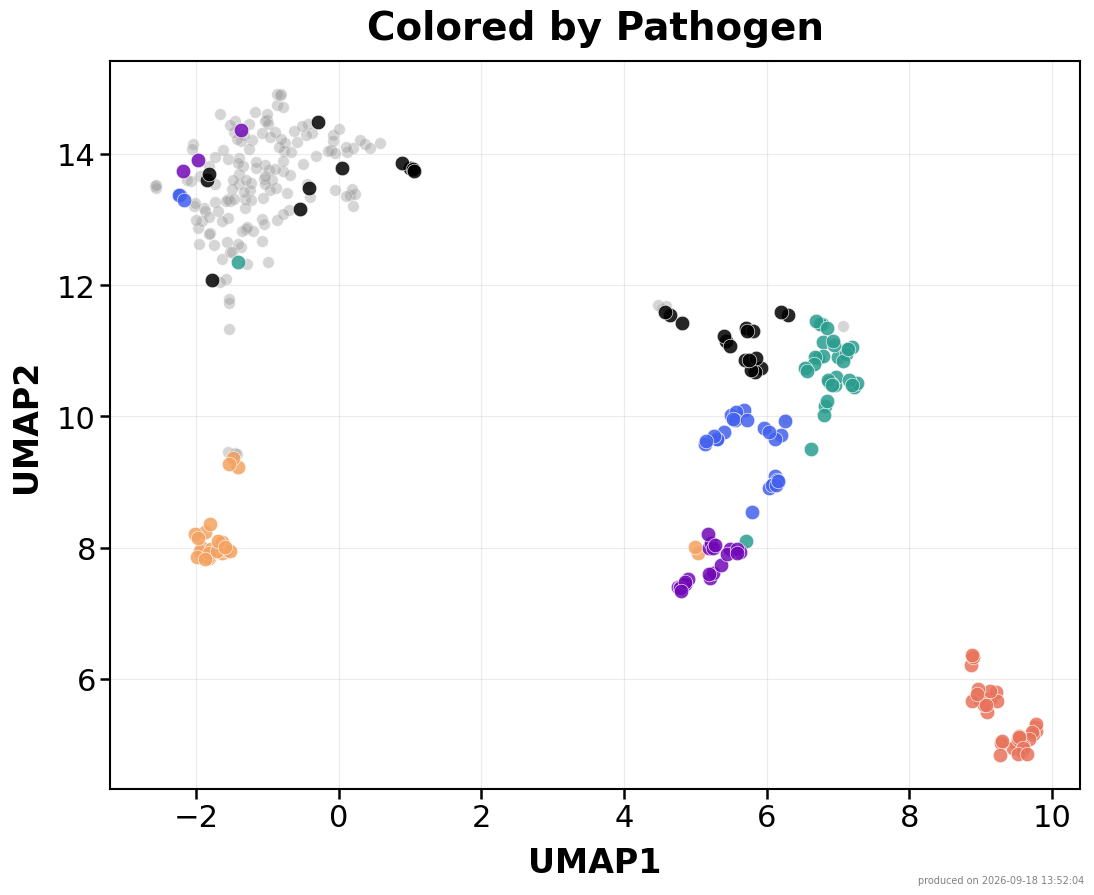

saved: UMAP_by_pathogen.png
pathogen_clean
Mock             153
Aspergillus       35
HSV1              34
Pseudomonas       29
Candida           28
HCMV              26
Mycobacterium     25


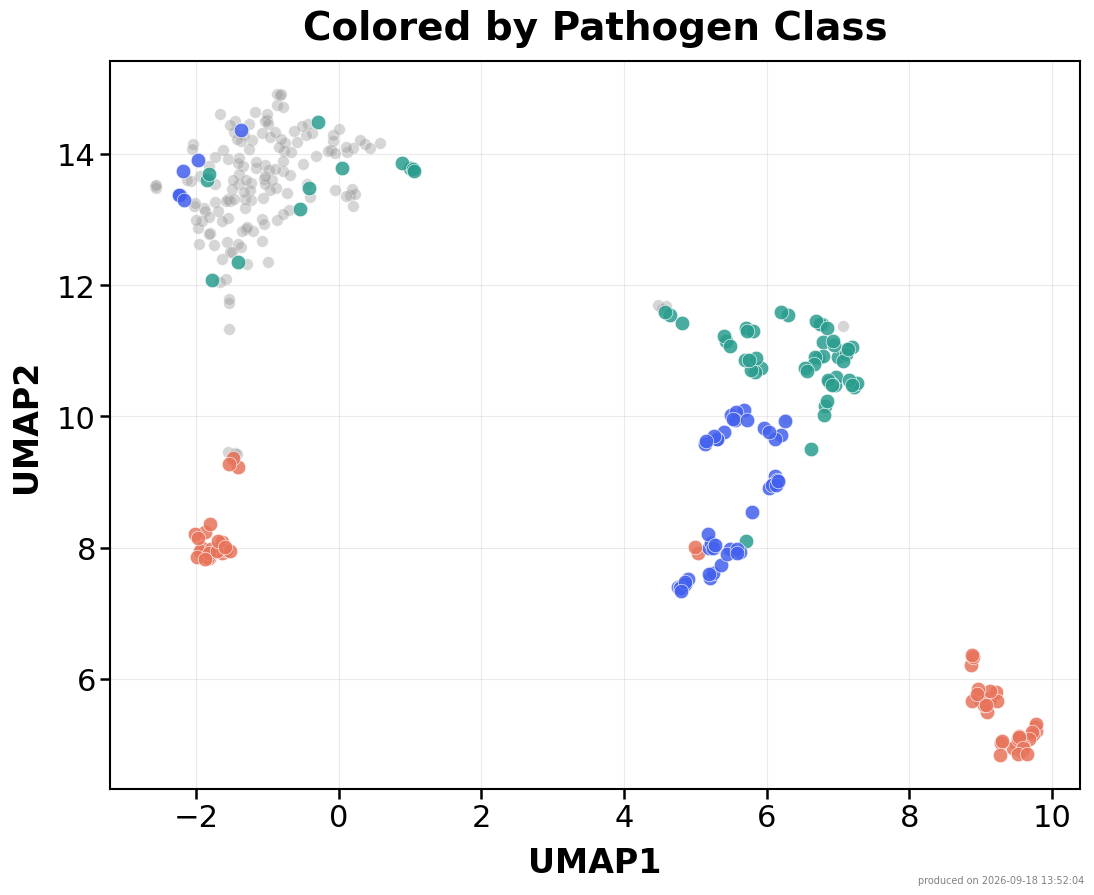

saved: UMAP_by_class.png
pathogen_class
Mock         153
Fungus        63
Virus         60
Bacterium     54


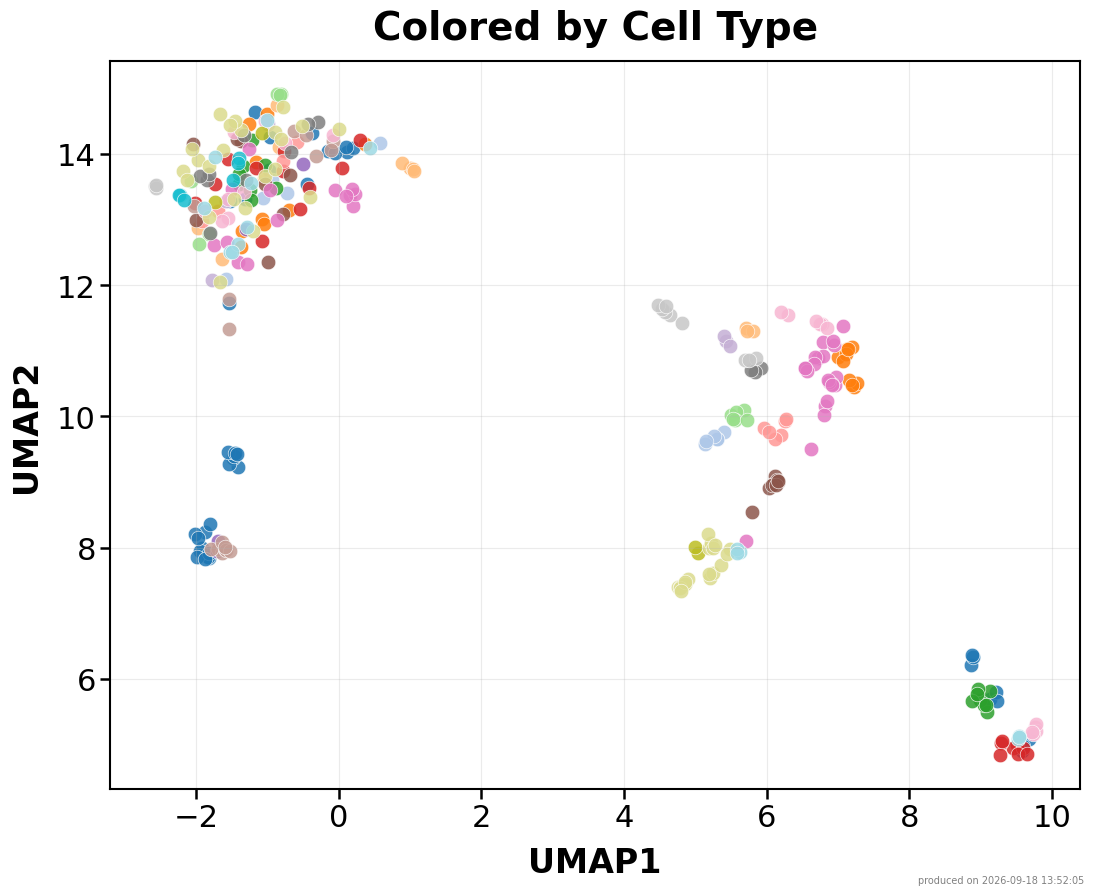

saved: UMAP_by_celltype.png
24 cell types
cell_type
THP1                           42
Monocyte-derived-Macrophage    36
ARPE19                         28
Dendritic                      19
Leukocytes                     17
HAP1                           16
MRC5                           16
HFF1                           13
HBE                            12
OralSquamousCellCarcinoma      12
Neutrophils                    12
A549                           12
Epithelial                     12
OKF6                           12
Calu3                          11
HLTE                           10
NPCs                            9
stemmacrophage                  9
nasopharyngealorganoids         6
sc-islets                       6
Keratinocyte                    6
HCT116                          6
RPTEC                           4
HS68                            4


In [97]:
from datetime import datetime

pathogen_colors = {
    'HSV1':          '#E8735A',
    'HCMV':          '#F4A261',
    'Aspergillus':   '#2A9D8F',
    'Candida':       '#000000',
    'Pseudomonas':   '#4361EE',
    'Mycobacterium': '#7209B7',
    'Mock':          '#999999',
}

class_colors = {
    'Virus':     '#E8735A',
    'Fungus':    '#2A9D8F',
    'Bacterium': '#4361EE',
    'Mock':      '#999999'
}

# ---- styling ----
FS_TITLE   = 28
FS_AXLABEL = 24
FS_TICK    = 22
DOT_SIZE   = 110
MOCK_SIZE  = 70
OUT        = r'C:\Users\mariaplumber\Downloads'


def style_axes(ax, title):
    ax.set_title(title, fontsize=FS_TITLE, fontweight='bold', pad=16)
    ax.set_xlabel('UMAP1', fontsize=FS_AXLABEL, fontweight='bold', labelpad=10)
    ax.set_ylabel('UMAP2', fontsize=FS_AXLABEL, fontweight='bold', labelpad=10)
    ax.tick_params(axis='both', which='major', labelsize=FS_TICK, width=1.8, length=7)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.grid(True, alpha=0.25)
    ax.set_facecolor('white')


def save_fig(fig, fname):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    fig.text(0.99, 0.01, f'produced on {timestamp}',
             ha='right', va='bottom', fontsize=7, color='gray')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.savefig(f"{OUT}/{fname}", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"saved: {fname}")


# ============================================================
# FIGURE 1 — by pathogen
# ============================================================
fig, ax = plt.subplots(figsize=(11, 9))
groups = ['Mock'] + [p for p in umap_df['pathogen_clean'].unique() if p != 'Mock']
for pathogen in groups:
    grp = umap_df[umap_df['pathogen_clean'] == pathogen]
    ax.scatter(
        grp['UMAP1'], grp['UMAP2'],
        c          = pathogen_colors.get(pathogen, '#999999'),
        s          = MOCK_SIZE if pathogen == 'Mock' else DOT_SIZE,
        alpha      = 0.4 if pathogen == 'Mock' else 0.85,
        edgecolors = 'white', linewidths = 0.5,
        zorder     = 1 if pathogen == 'Mock' else 3
    )
style_axes(ax, 'Colored by Pathogen')
save_fig(fig, 'UMAP_by_pathogen.png')
print(umap_df['pathogen_clean'].value_counts().to_string())


# ============================================================
# FIGURE 2 — by pathogen class
# ============================================================
fig, ax = plt.subplots(figsize=(11, 9))
for cls in ['Mock', 'Virus', 'Fungus', 'Bacterium']:
    grp = umap_df[umap_df['pathogen_class'] == cls]
    ax.scatter(
        grp['UMAP1'], grp['UMAP2'],
        c          = class_colors[cls],
        s          = MOCK_SIZE if cls == 'Mock' else DOT_SIZE,
        alpha      = 0.4 if cls == 'Mock' else 0.85,
        edgecolors = 'white', linewidths = 0.5,
        zorder     = 1 if cls == 'Mock' else 3
    )
style_axes(ax, 'Colored by Pathogen Class')
save_fig(fig, 'UMAP_by_class.png')
print(umap_df['pathogen_class'].value_counts().to_string())


# ============================================================
# FIGURE 3 — by cell type
# ============================================================
fig, ax = plt.subplots(figsize=(11, 9))
cell_types = sorted(umap_df['cell_type'].astype(str).unique())
cmap = plt.get_cmap('tab20', len(cell_types))
for i, ct in enumerate(cell_types):
    grp = umap_df[umap_df['cell_type'].astype(str) == ct]
    ax.scatter(
        grp['UMAP1'], grp['UMAP2'],
        c=[cmap(i)], s=DOT_SIZE, alpha=0.85,
        edgecolors='white', linewidths=0.5
    )
style_axes(ax, 'Colored by Cell Type')
save_fig(fig, 'UMAP_by_celltype.png')
print(f"{len(cell_types)} cell types")
print(umap_df['cell_type'].value_counts().to_string())

In [98]:
import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix)

try:
    import umap
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False

OUT = r'C:\Users\mariaplumber\Downloads\pipeline_outputs'
os.makedirs(OUT, exist_ok=True)

PATHS   = ['HSV1', 'HCMV', 'Aspergillus', 'Candida', 'Pseudomonas', 'Mycobacterium']
NAMEMAP = {'Pseuaer': 'Pseudomonas', 'Myctub': 'Mycobacterium'}
META    = ['pathogen', 'condition', 'study', 'cell_type', 'pathogen_clean']
SEED    = 0

df = lfc_df_with_mock.copy()
df['pathogen_clean'] = df['pathogen'].replace(NAMEMAP)

GENES = [c for c in df.columns if c not in META]

# fail loudly rather than training on the wrong panel
assert len(GENES) > 0, "no gene columns found — check META against df.columns"
bad = df[GENES].dtypes[~df[GENES].dtypes.apply(pd.api.types.is_numeric_dtype)]
assert bad.empty, f"non-numeric columns leaked into GENES: {list(bad.index)}"
unexpected = set(df['pathogen_clean']) - set(PATHS) - {'Mock'}
assert not unexpected, f"unexpected pathogen labels: {unexpected}"

df['_mag'] = np.linalg.norm(df[GENES].astype(float).values, axis=1)

inf = df[df['condition'] == 'infected'].reset_index(drop=True)

df.to_excel(r'C:\Users\mariaplumber\Downloads\combined_lfc_matrix.xlsx')

print(f"df:    {df.shape[0]} samples x {len(GENES)} genes (+ {len(META)} metadata cols)")
print(f"inf:   {len(inf)} infected samples")
print(f"NaNs in gene panel: {int(df[GENES].isna().sum().sum())}")
print(f"\nClass counts (pathogen_clean):")
print(df['pathogen_clean'].value_counts().to_string())
print(f"\nStudies: {df['study'].nunique()}   cell types: {df['cell_type'].nunique()}")
print("\nSetup complete.")

df:    330 samples x 605 genes (+ 5 metadata cols)
inf:   177 infected samples
NaNs in gene panel: 0

Class counts (pathogen_clean):
pathogen_clean
Mock             153
Aspergillus       35
HSV1              34
Pseudomonas       29
Candida           28
HCMV              26
Mycobacterium     25

Studies: 38   cell types: 24

Setup complete.


In [99]:
df = lfc_df_with_mock.copy()

META = ['pathogen', 'condition', 'study', 'cell_type', 'pathogen_clean']
GENES = [c for c in df.columns if c not in META]

print(df.columns.tolist()[:10])
print(df.columns.tolist()[-10:])
print(f"\nTotal columns: {len(df.columns)}")
print(f"\nMETA columns actually found in df: {[c for c in META if c in df.columns]}")
print(f"META columns in META list but missing from df: {[c for c in META if c not in df.columns]}")

df['_mag'] = np.linalg.norm(df[GENES].astype(float).values, axis=1)

inf = df[df.condition == 'infected'].reset_index(drop=True)
print(f"df shape: {df.shape} | GENES: {len(GENES)} | infected samples: {len(inf)}")

['ABCG1', 'ABCG2', 'ABHD3', 'AC093724.2', 'AC116366.6', 'ACOT4', 'ACRC', 'ACSL1', 'ADAMTS2', 'ADAMTS5']
['ZNF106', 'ZNF280B', 'ZNF296', 'ZNF560', 'ZNF608', 'ZNF704', 'pathogen', 'condition', 'study', 'cell_type']

Total columns: 609

META columns actually found in df: ['pathogen', 'condition', 'study', 'cell_type']
META columns in META list but missing from df: ['pathogen_clean']
df shape: (330, 610) | GENES: 605 | infected samples: 177


In [100]:
def rf():  return RandomForestClassifier(400, class_weight='balanced', random_state=SEED, n_jobs=-1)
def svm(): return make_pipeline(StandardScaler(), LinearSVC(class_weight='balanced', C=0.5, max_iter=5000))

def loso(X, y, groups, make=rf, grouped=True, topN=None):
    splitter = (StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, groups)
                if grouped else StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y))
    oof = np.array(['?']*len(y), dtype=object)
    for tr, te in splitter:
        Xtr, Xte = X[tr], X[te]
        if topN is not None:
            sel = RandomForestClassifier(150, class_weight='balanced', random_state=SEED, n_jobs=-1).fit(Xtr, y[tr])
            idx = np.argsort(sel.feature_importances_)[::-1][:topN]
            Xtr, Xte = Xtr[:, idx], Xte[:, idx]
        oof[te] = make().fit(Xtr, y[tr]).predict(Xte)
    return oof

print("CV helpers defined.")

CV helpers defined.


In [101]:
# ============================================================
# TABLE 2 — FULL GENE SPACE (no robust-panel restriction)
# ============================================================
tpm_gene_pooled = pd.concat(
    [tpm_gene_by_pathogen[g] for g in tpm_gene_by_pathogen], axis=1
) if 'tpm_gene_by_pathogen' in dir() else tpm_gene_combined

meta = meta_all.copy()
meta['pathogen'] = meta['pathogen'].replace(
    {'Pseuaer': 'Pseudomonas', 'Myctub': 'Mycobacterium'}
)

recs = []
for study in meta['study'].unique():
    sm   = meta[meta['study'] == study]
    mock = sm[sm['condition'] == 'mock'].index.tolist()
    infd = sm[sm['condition'] != 'mock'].index.tolist()
    if not mock or not infd:
        continue
    mock_mean = np.log2(tpm_gene_pooled[mock] + 1).mean(axis=1)
    for s in infd + mock:
        lfc = np.log2(tpm_gene_pooled[s] + 1) - mock_mean
        r = lfc.to_dict()
        r.update(sample_id=s,
                 pathogen=('Mock' if s in mock else meta.loc[s, 'pathogen']),
                 condition=meta.loc[s, 'condition'],
                 study=study,
                 cell_type=meta.loc[s, 'cell_type'])
        recs.append(r)

lfc_all = pd.DataFrame(recs).set_index('sample_id')
meta_cols_all = ['pathogen', 'condition', 'study', 'cell_type']
genes_all = [c for c in lfc_all.columns if c not in meta_cols_all]

Xa = lfc_all[genes_all].fillna(0).astype(float).values
ya = lfc_all['pathogen'].astype(str).values
ga = lfc_all['study'].astype(str).values

print(f"Samples: {Xa.shape[0]} | Genes: {Xa.shape[1]} | Studies: {len(set(ga))}")
print(f"Classes ({len(set(ya))}): {sorted(set(ya))}")

rows = []
for N in [8, 15, 25, 40, 60, 90, 150, 250, 400, 605]:
    ba_logo    = balanced_accuracy_score(ya, logo_cv(Xa, ya, ga, N))
    ba_grouped = balanced_accuracy_score(ya, grouped_cv(Xa, ya, ga, True,  N))
    ba_random  = balanced_accuracy_score(ya, grouped_cv(Xa, ya, ga, False, N))
    rows.append({'n_genes': N, 'LOGO': round(ba_logo, 3),
                 'grouped_5fold': round(ba_grouped, 3), 'random_5fold': round(ba_random, 3)})
    print(f"n_genes={N:4d} | LOGO={ba_logo:.3f} | grouped={ba_grouped:.3f} | random={ba_random:.3f}")

table2_full = pd.DataFrame(rows)
print(f"\n{table2_full.to_string(index=False)}")

Samples: 330 | Genes: 35300 | Studies: 38
Classes (7): ['Aspergillus', 'Candida', 'HCMV', 'HSV1', 'Mock', 'Mycobacterium', 'Pseudomonas']
n_genes=   8 | LOGO=0.519 | grouped=0.423 | random=0.756
n_genes=  15 | LOGO=0.576 | grouped=0.449 | random=0.779
n_genes=  25 | LOGO=0.564 | grouped=0.436 | random=0.818
n_genes=  40 | LOGO=0.586 | grouped=0.554 | random=0.848
n_genes=  60 | LOGO=0.573 | grouped=0.581 | random=0.848
n_genes=  90 | LOGO=0.578 | grouped=0.562 | random=0.867
n_genes= 150 | LOGO=0.576 | grouped=0.584 | random=0.845
n_genes= 250 | LOGO=0.599 | grouped=0.570 | random=0.859
n_genes= 400 | LOGO=0.568 | grouped=0.571 | random=0.861
n_genes= 605 | LOGO=0.582 | grouped=0.571 | random=0.872

 n_genes  LOGO  grouped_5fold  random_5fold
       8 0.519          0.423         0.756
      15 0.576          0.449         0.779
      25 0.564          0.436         0.818
      40 0.586          0.554         0.848
      60 0.573          0.581         0.848
      90 0.578          0.5

In [102]:
# ============================================================
# TABLE 2 — 605-GENE ROBUST PANEL
# ============================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

SEED = 0

def grouped_cv(X, y, groups, grouped=True, topN=None):
    """5-fold CV. grouped=True keeps each study within one fold."""
    splitter = (StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X, y, groups)
                if grouped else StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y))
    oof = np.array(['?'] * len(y), dtype=object)
    for tr, te in splitter:
        Xtr, Xte = X[tr], X[te]
        if topN is not None:
            sel = RandomForestClassifier(150, class_weight='balanced',
                                         random_state=SEED, n_jobs=-1).fit(Xtr, y[tr])
            idx = np.argsort(sel.feature_importances_)[::-1][:topN]
            Xtr, Xte = Xtr[:, idx], Xte[:, idx]
        oof[te] = RandomForestClassifier(400, class_weight='balanced',
                                         random_state=SEED, n_jobs=-1).fit(Xtr, y[tr]).predict(Xte)
    return oof


def logo_cv(X, y, groups, topN=None):
    """True leave-one-study-out: one fold per study."""
    oof = np.array(['?'] * len(y), dtype=object)
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        Xtr, Xte = X[tr], X[te]
        if topN is not None:
            sel = RandomForestClassifier(150, class_weight='balanced',
                                         random_state=SEED, n_jobs=-1).fit(Xtr, y[tr])
            idx = np.argsort(sel.feature_importances_)[::-1][:topN]
            Xtr, Xte = Xtr[:, idx], Xte[:, idx]
        oof[te] = RandomForestClassifier(400, class_weight='balanced',
                                         random_state=SEED, n_jobs=-1).fit(Xtr, y[tr]).predict(Xte)
    return oof


meta_cols = ['pathogen', 'condition', 'study', 'cell_type', 'pathogen_clean', '_mag']
gene_cols = [c for c in lfc_df_with_mock.columns if c not in meta_cols]

X7 = lfc_df_with_mock[gene_cols].fillna(0).astype(float).values
y7 = lfc_df_with_mock['pathogen'].replace(
    {'Myctub': 'Mycobacterium', 'Pseuaer': 'Pseudomonas'}
).astype(str).values
g7 = lfc_df_with_mock['study'].astype(str).values

print(f"Samples: {X7.shape[0]} | Genes: {X7.shape[1]} | Studies: {len(set(g7))}")
print(f"Classes ({len(set(y7))}): {sorted(set(y7))}")

rows = []
for N in [8, 15, 25, 40, 60, 90, 150, 250, 400, len(gene_cols)]:
    if N > len(gene_cols):
        continue
    ba_logo    = balanced_accuracy_score(y7, logo_cv(X7, y7, g7, N))
    ba_grouped = balanced_accuracy_score(y7, grouped_cv(X7, y7, g7, True,  N))
    ba_random  = balanced_accuracy_score(y7, grouped_cv(X7, y7, g7, False, N))
    rows.append({'n_genes': N, 'LOGO': round(ba_logo, 3),
                 'grouped_5fold': round(ba_grouped, 3), 'random_5fold': round(ba_random, 3)})
    print(f"n_genes={N:4d} | LOGO={ba_logo:.3f} | grouped={ba_grouped:.3f} | random={ba_random:.3f}")

table2_panel = pd.DataFrame(rows)
print(f"\n{table2_panel.to_string(index=False)}")

Samples: 330 | Genes: 605 | Studies: 38
Classes (7): ['Aspergillus', 'Candida', 'HCMV', 'HSV1', 'Mock', 'Mycobacterium', 'Pseudomonas']
n_genes=   8 | LOGO=0.564 | grouped=0.579 | random=0.768
n_genes=  15 | LOGO=0.610 | grouped=0.605 | random=0.838
n_genes=  25 | LOGO=0.633 | grouped=0.614 | random=0.861
n_genes=  40 | LOGO=0.679 | grouped=0.667 | random=0.893
n_genes=  60 | LOGO=0.709 | grouped=0.633 | random=0.904
n_genes=  90 | LOGO=0.692 | grouped=0.651 | random=0.908
n_genes= 150 | LOGO=0.685 | grouped=0.653 | random=0.907
n_genes= 250 | LOGO=0.699 | grouped=0.637 | random=0.907
n_genes= 400 | LOGO=0.699 | grouped=0.621 | random=0.912
n_genes= 605 | LOGO=0.679 | grouped=0.628 | random=0.907

 n_genes  LOGO  grouped_5fold  random_5fold
       8 0.564          0.579         0.768
      15 0.610          0.605         0.838
      25 0.633          0.614         0.861
      40 0.679          0.667         0.893
      60 0.709          0.633         0.904
      90 0.692          0.651

In [103]:
# ============================================================
# MULTI-SEED PANEL SWEEP — is the peak stable?
# ============================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.base import clone

SEEDS   = [0, 1, 2, 3]
N_LIST  = [15, 25, 40, 60, 90, 150, 250, 605]


def cv_predict(X, y, groups, model, scheme, topN, seed):
    """scheme: 'logo' | 'grouped' | 'random'"""
    if scheme == 'logo':
        splits = LeaveOneGroupOut().split(X, y, groups)
    elif scheme == 'grouped':
        splits = StratifiedGroupKFold(5, shuffle=True, random_state=seed).split(X, y, groups)
    else:
        splits = StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y)

    oof = np.array(['?'] * len(y), dtype=object)
    for tr, te in splits:
        Xtr, Xte = X[tr], X[te]
        if topN is not None:
            sel = RandomForestClassifier(150, class_weight='balanced',
                                         random_state=seed, n_jobs=-1).fit(Xtr, y[tr])
            idx = np.argsort(sel.feature_importances_)[::-1][:topN]
            Xtr, Xte = Xtr[:, idx], Xte[:, idx]
        m = clone(model)
        if hasattr(m, 'random_state'):
            m.set_params(random_state=seed)
        oof[te] = m.fit(Xtr, y[tr]).predict(Xte)
    return oof


rows = []
for scheme in ['logo', 'grouped']:
    for N in N_LIST:
        scores = []
        for seed in SEEDS:
            rf_s = RandomForestClassifier(400, class_weight='balanced', n_jobs=-1)
            scores.append(balanced_accuracy_score(
                y7, cv_predict(X7, y7, g7, rf_s, scheme, N, seed)))
        rows.append({'scheme': scheme, 'n_genes': N,
                     'mean': np.mean(scores), 'sd': np.std(scores),
                     'min': np.min(scores), 'max': np.max(scores),
                     'per_seed': [round(s, 3) for s in scores]})
        print(f"{scheme:8s} N={N:4d} | {np.mean(scores):.3f} ± {np.std(scores):.3f}  "
              f"(range {np.min(scores):.3f}–{np.max(scores):.3f})  {[round(s,3) for s in scores]}")

seed_sweep = pd.DataFrame(rows)

print("\n================ SUMMARY ================")
for scheme in ['logo', 'grouped']:
    sub = seed_sweep[seed_sweep['scheme'] == scheme]
    best = sub.loc[sub['mean'].idxmax()]
    print(f"\n{scheme}: best mean at N={int(best['n_genes'])} "
          f"({best['mean']:.3f} ± {best['sd']:.3f})")
    # which N wins for each individual seed
    wins = []
    for i, seed in enumerate(SEEDS):
        per_n = {int(r['n_genes']): r['per_seed'][i] for _, r in sub.iterrows()}
        wins.append(max(per_n, key=per_n.get))
    print(f"  peak N per seed: {wins}")

print(f"\n{seed_sweep[['scheme','n_genes','mean','sd','min','max']].round(3).to_string(index=False)}")

logo     N=  15 | 0.631 ± 0.023  (range 0.607–0.662)  [np.float64(0.61), np.float64(0.662), np.float64(0.607), np.float64(0.646)]
logo     N=  25 | 0.660 ± 0.022  (range 0.633–0.690)  [np.float64(0.633), np.float64(0.67), np.float64(0.69), np.float64(0.646)]
logo     N=  40 | 0.672 ± 0.008  (range 0.658–0.679)  [np.float64(0.679), np.float64(0.675), np.float64(0.674), np.float64(0.658)]
logo     N=  60 | 0.693 ± 0.017  (range 0.670–0.709)  [np.float64(0.709), np.float64(0.709), np.float64(0.67), np.float64(0.685)]
logo     N=  90 | 0.696 ± 0.017  (range 0.670–0.715)  [np.float64(0.692), np.float64(0.715), np.float64(0.706), np.float64(0.67)]
logo     N= 150 | 0.696 ± 0.007  (range 0.685–0.704)  [np.float64(0.685), np.float64(0.699), np.float64(0.704), np.float64(0.694)]
logo     N= 250 | 0.689 ± 0.006  (range 0.681–0.699)  [np.float64(0.699), np.float64(0.689), np.float64(0.689), np.float64(0.681)]
logo     N= 605 | 0.682 ± 0.009  (range 0.669–0.694)  [np.float64(0.679), np.float64(0.6

n_genes=   8 | RF honest=0.579 | SVM honest=0.651 | RF leaky=0.768 | SVM leaky=0.757
n_genes=  15 | RF honest=0.605 | SVM honest=0.692 | RF leaky=0.838 | SVM leaky=0.849
n_genes=  25 | RF honest=0.614 | SVM honest=0.712 | RF leaky=0.861 | SVM leaky=0.875
n_genes=  40 | RF honest=0.667 | SVM honest=0.792 | RF leaky=0.893 | SVM leaky=0.862
n_genes=  60 | RF honest=0.633 | SVM honest=0.774 | RF leaky=0.904 | SVM leaky=0.886
n_genes=  90 | RF honest=0.651 | SVM honest=0.758 | RF leaky=0.908 | SVM leaky=0.913
n_genes= 150 | RF honest=0.653 | SVM honest=0.755 | RF leaky=0.907 | SVM leaky=0.930
n_genes= 250 | RF honest=0.637 | SVM honest=0.760 | RF leaky=0.907 | SVM leaky=0.939
n_genes= 400 | RF honest=0.621 | SVM honest=0.774 | RF leaky=0.912 | SVM leaky=0.941
n_genes= 605 | RF honest=0.628 | SVM honest=0.779 | RF leaky=0.907 | SVM leaky=0.941


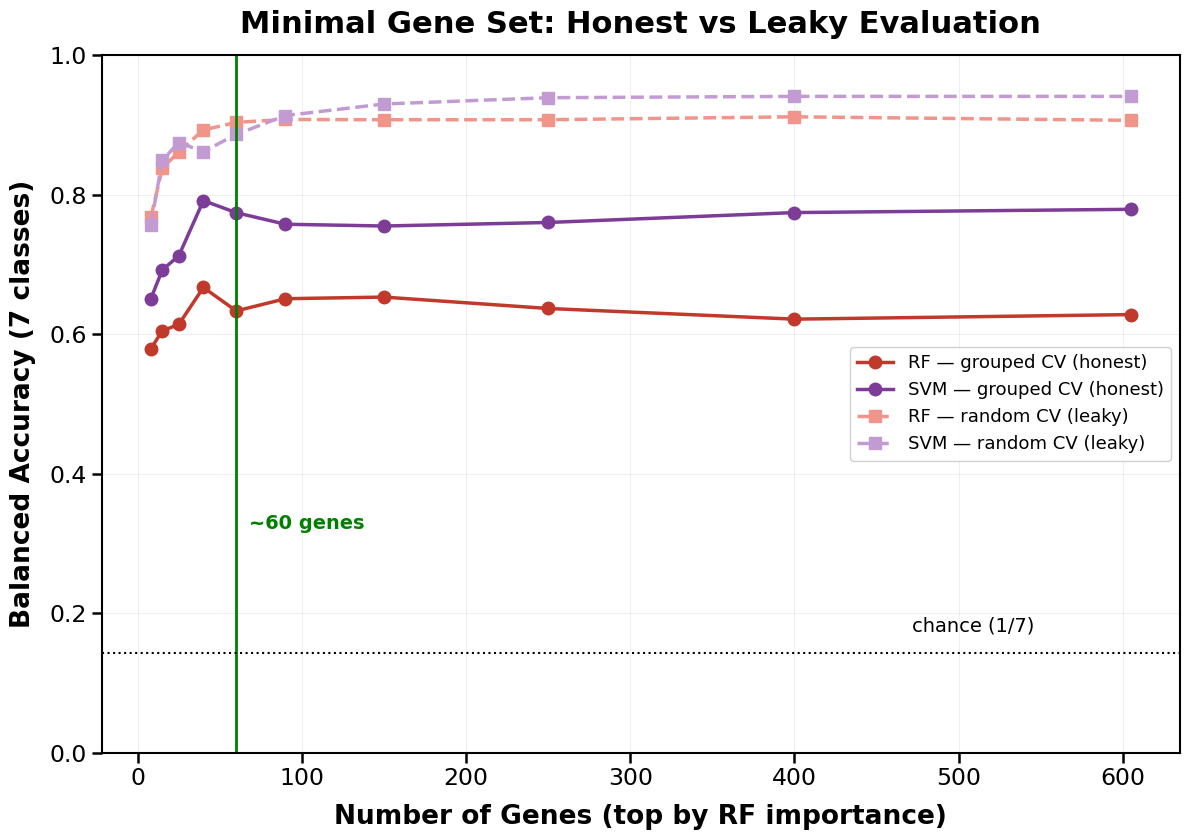


Sweep results:
 n_genes  rf_honest  svm_honest  rf_leaky  svm_leaky
       8      0.579       0.651     0.768      0.757
      15      0.605       0.692     0.838      0.849
      25      0.614       0.712     0.861      0.875
      40      0.667       0.792     0.893      0.862
      60      0.633       0.774     0.904      0.886
      90      0.651       0.758     0.908      0.913
     150      0.653       0.755     0.907      0.930
     250      0.637       0.760     0.907      0.939
     400      0.621       0.774     0.912      0.941
     605      0.628       0.779     0.907      0.941


In [104]:
N_VALUES_SWEEP = [8, 15, 25, 40, 60, 90, 150, 250, 400, len(GENES)]

results_sweep = []
for N in N_VALUES_SWEEP:
    rf_honest = balanced_accuracy_score(y7, loso(X7, y7, g7, rf, True, N))
    rf_leaky  = balanced_accuracy_score(y7, loso(X7, y7, g7, rf, False, N))
    svm_honest = balanced_accuracy_score(y7, loso(X7, y7, g7, svm, True, N))
    svm_leaky  = balanced_accuracy_score(y7, loso(X7, y7, g7, svm, False, N))
    results_sweep.append([N, rf_honest, svm_honest, rf_leaky, svm_leaky])
    print(f"n_genes={N:4d} | RF honest={rf_honest:.3f} | SVM honest={svm_honest:.3f} | "
          f"RF leaky={rf_leaky:.3f} | SVM leaky={svm_leaky:.3f}")

sweep_df = pd.DataFrame(results_sweep,
                        columns=['n_genes', 'rf_honest', 'svm_honest', 'rf_leaky', 'svm_leaky'])

# ---- font sizes (tweak here) ----
FS_TITLE   = 22
FS_AXLABEL = 19
FS_TICK    = 17
FS_LEGEND  = 13
FS_ANNOT   = 14

# ---- plot ----
fig, ax = plt.subplots(figsize=(12, 8.5))

ax.plot(sweep_df.n_genes, sweep_df.rf_honest, 'o-', color='#c0392b', label='RF — grouped CV (honest)', linewidth=2.5, markersize=9)
ax.plot(sweep_df.n_genes, sweep_df.svm_honest, 'o-', color='#7d3c98', label='SVM — grouped CV (honest)', linewidth=2.5, markersize=9)
ax.plot(sweep_df.n_genes, sweep_df.rf_leaky, 's--', color='#f1948a', label='RF — random CV (leaky)', linewidth=2.5, markersize=9)
ax.plot(sweep_df.n_genes, sweep_df.svm_leaky, 's--', color='#c39bd3', label='SVM — random CV (leaky)', linewidth=2.5, markersize=9)

# mark chosen minimal gene set (N_BEST = 60, from your elbow analysis)
N_BEST = 60
ax.axvline(N_BEST, color='green', linewidth=2)
ax.text(N_BEST + 8, 0.32, f'~{N_BEST} genes', color='green', fontsize=FS_ANNOT, fontweight='bold')

# chance line
ax.axhline(1/7, color='black', linestyle=':', linewidth=1.5)
ax.text(sweep_df.n_genes.max()*0.78, 1/7 + 0.03, 'chance (1/7)', fontsize=FS_ANNOT, color='black')

ax.set_xlabel('Number of Genes (top by RF importance)', fontsize=FS_AXLABEL, fontweight='bold', labelpad=10)
ax.set_ylabel('Balanced Accuracy (7 classes)', fontsize=FS_AXLABEL, fontweight='bold', labelpad=10)
ax.set_title('Minimal Gene Set: Honest vs Leaky Evaluation', fontsize=FS_TITLE, fontweight='bold', pad=16)
ax.tick_params(axis='both', which='major', labelsize=FS_TICK, width=1.8, length=7)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=FS_LEGEND, loc='center right', framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{OUT}/fig_minimal_geneset_honest_vs_leaky.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nSweep results:")
print(sweep_df.round(3).to_string(index=False))

7-class LOGO balanced accuracy (60 genes): 0.709

        class   n  recall
  Aspergillus  35    0.89
      Candida  28    0.61
         HCMV  26    0.81
         HSV1  34    0.82
         Mock 153    0.99
Mycobacterium  25    0.64
  Pseudomonas  29    0.21


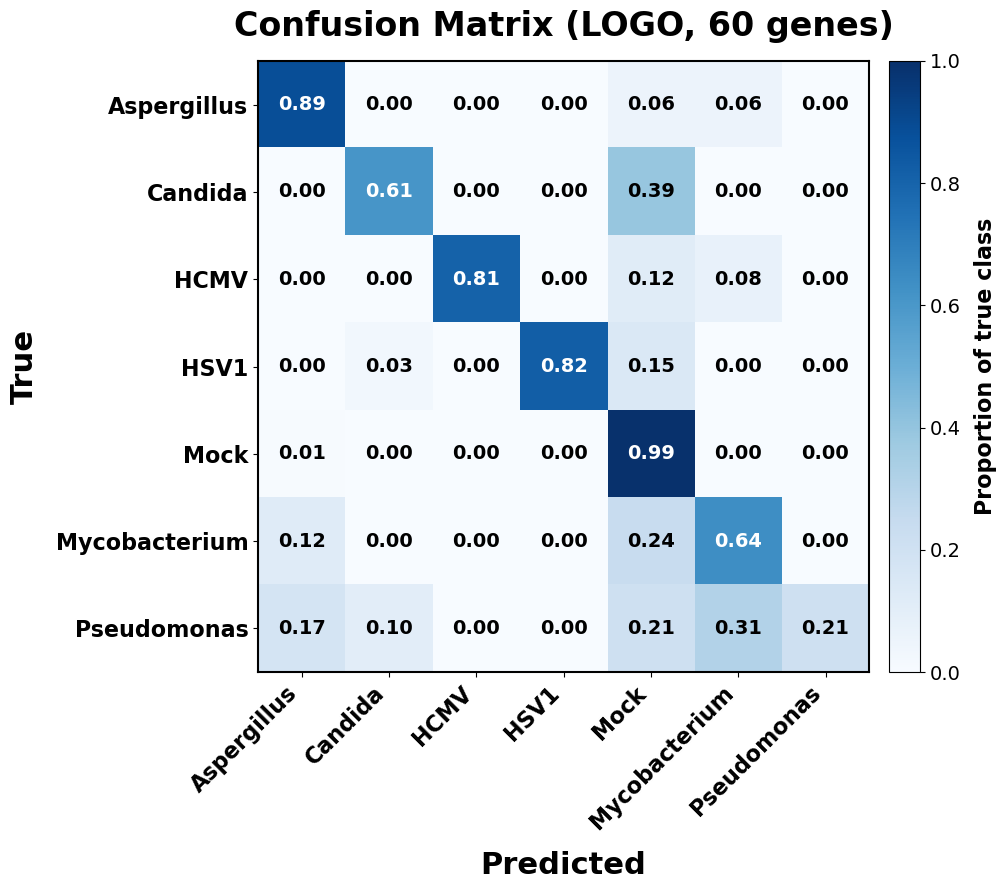

In [105]:
# ============================================================
# LOGO CONFUSION MATRIX — 7 CLASSES (mock included)
# ============================================================
OUTDIR = r'C:\Users\mariaplumber\Downloads\pipeline_outputs'
os.makedirs(OUTDIR, exist_ok=True)

N_BEST = 60

rf7 = RandomForestClassifier(400, class_weight='balanced', random_state=SEED, n_jobs=-1)
oof7 = logo_cv(X7, y7, g7, N_BEST)

ba7 = balanced_accuracy_score(y7, oof7)
print(f"7-class LOGO balanced accuracy ({N_BEST} genes): {ba7:.3f}")

classes7 = sorted(set(y7))
perclass = pd.DataFrame(
    [[c, int((y7 == c).sum()), round(recall_score(y7 == c, oof7 == c), 2)] for c in classes7],
    columns=['class', 'n', 'recall'])
print(f"\n{perclass.to_string(index=False)}")

cm7  = confusion_matrix(y7, oof7, labels=classes7).astype(float)
cmn7 = cm7 / cm7.sum(1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cmn7, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(classes7)))
ax.set_yticks(range(len(classes7)))
ax.set_xticklabels(classes7, rotation=45, ha='right', fontsize=16, fontweight='bold')
ax.set_yticklabels(classes7, fontsize=16, fontweight='bold')

for i in range(len(classes7)):
    for j in range(len(classes7)):
        ax.text(j, i, f"{cmn7[i,j]:.2f}", ha='center', va='center',
                color='white' if cmn7[i,j] > .5 else 'black',
                fontsize=14, fontweight='bold')

ax.set_xlabel('Predicted', fontsize=22, fontweight='bold', labelpad=12)
ax.set_ylabel('True', fontsize=22, fontweight='bold', labelpad=12)
ax.set_title(f'Confusion Matrix (LOGO, {N_BEST} genes)',
             fontsize=24, fontweight='bold', pad=18)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

cbar = plt.colorbar(im, fraction=.046, pad=0.03)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Proportion of true class', fontsize=16, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.savefig(f"{OUT}/confusion_LOGO_7class_{N_BEST}genes.png", dpi=300, bbox_inches='tight')
plt.show()

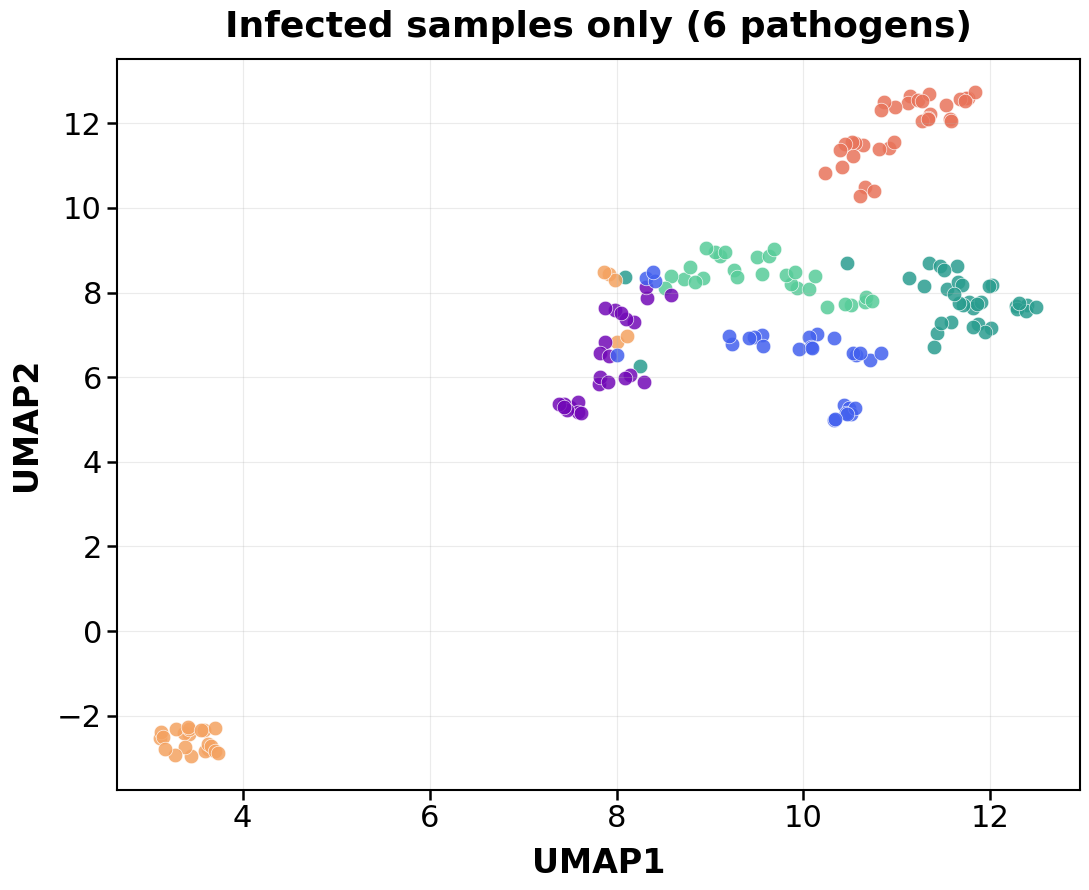

pathogen
Aspergillus      35
HSV1             34
Pseudomonas      29
Candida          28
HCMV             26
Mycobacterium    25


In [62]:
# ============================================================
# UMAP — INFECTED ONLY (6 classes)
# ============================================================
import umap

X6_scaled = StandardScaler().fit_transform(inf_df[gene_cols].fillna(0).values)

reducer6 = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
umap6 = reducer6.fit_transform(X6_scaled)

umap6_df = pd.DataFrame(umap6, index=inf_df.index, columns=['UMAP1', 'UMAP2'])
umap6_df['pathogen'] = y6
umap6_df['study']     = inf_df['study'].values
umap6_df['cell_type'] = inf_df['cell_type'].values

colors6 = {
    'HSV1': '#E8735A', 'HCMV': '#F4A261', 'Aspergillus': '#2A9D8F',
    'Candida': '#57CC99', 'Pseudomonas': '#4361EE', 'Mycobacterium': '#7209B7',
}

fig, ax = plt.subplots(figsize=(11, 9))
for p in sorted(colors6):
    grp = umap6_df[umap6_df['pathogen'] == p]
    ax.scatter(grp['UMAP1'], grp['UMAP2'], c=colors6[p], s=110, alpha=0.85,
               edgecolors='white', linewidths=0.5)

ax.set_xlabel('UMAP1', fontsize=24, fontweight='bold', labelpad=10)
ax.set_ylabel('UMAP2', fontsize=24, fontweight='bold', labelpad=10)
ax.set_title('Infected samples only (6 pathogens)', fontsize=26, fontweight='bold', pad=16)
ax.tick_params(axis='both', which='major', labelsize=22, width=1.8, length=7)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.grid(True, alpha=0.25)
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig(f"{OUT}/UMAP_infected_only_6class.png", dpi=300, bbox_inches='tight')
plt.show()

print(umap6_df['pathogen'].value_counts().to_string())

In [108]:
from collections import Counter

splitter = StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X7, y7, g7)

selection_counts = Counter()
for tr, te in splitter:
    sel = RandomForestClassifier(150, class_weight='balanced', random_state=SEED, n_jobs=-1).fit(X7[tr], y7[tr])
    idx = np.argsort(sel.feature_importances_)[::-1][:60]
    for i in idx:
        selection_counts[gene_cols[i]] += 1

freq_df = pd.DataFrame(selection_counts.items(), columns=['gene', 'n_folds_selected'])
freq_df = freq_df.sort_values('n_folds_selected', ascending=False)
print(freq_df.to_string(index=False))

freq_df.to_csv(r'C:\Users\mariaplumber\Downloads\gene_selection_frequency_60_across_folds.csv', index=False)

        gene  n_folds_selected
      CCL3L3                 5
    SERPINB7                 5
    PAFAH1B1                 5
        CCL4                 5
    SERPINB4                 5
        OTX1                 5
         AXL                 5
       RCAN1                 5
        AREG                 5
      SEC11C                 5
      CCL4L2                 5
     C6orf89                 4
        CCL3                 4
       MAP1A                 4
        COMT                 4
      TRIM22                 4
       HCAR2                 4
        IL1A                 4
       PLAUR                 4
    RASGEF1B                 4
        EBI3                 4
       PTGS2                 4
        RBP7                 4
       IFI44                 3
       DSCC1                 3
        SVIP                 3
      IFITM1                 3
     SIGLEC1                 3
      CYB5D1                 3
      SLC2A3                 3
      DOLPP1                 3
        

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\mariaplumber\\Downloads\\gene_selection_frequency_60_across_folds.csv'

In [109]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

OUTDIR = r'C:\Users\mariaplumber\Downloads\umap_gene_panels_by_pathogen'
os.makedirs(OUTDIR, exist_ok=True)

THRESH   = 1.0
CAP      = 4.01
PER_PAGE = 6          # 3 cols x 2 rows

freq_df = pd.read_csv(
    r'C:\Users\mariaplumber\Downloads\gene_selection_frequency_60_across_folds.csv'
).sort_values('n_folds_selected', ascending=False)

# --- resolve symbols case-insensitively against the matrix ---
lookup = {c.upper(): c for c in gene_cols}
genes, missing = [], []
for g, nf in zip(freq_df['gene'], freq_df['n_folds_selected']):
    key = str(g).upper()
    (genes.append((lookup[key], nf)) if key in lookup else missing.append(g))

if missing:
    print(f"NOT IN MATRIX ({len(missing)}): {missing}")
print(f"Plotting {len(genes)} genes across "
      f"{int(np.ceil(len(genes)/PER_PAGE))} pages")

coords = umap_df[['UMAP1', 'UMAP2']]
reds   = plt.get_cmap('Reds')

xlim = (coords['UMAP1'].min() - 0.5, coords['UMAP1'].max() + 0.5)
ylim = (coords['UMAP2'].min() - 0.5, coords['UMAP2'].max() + 0.5)

pdf_path = os.path.join(OUTDIR, 'UMAP_all_selected_genes.pdf')
with PdfPages(pdf_path) as pdf:
    for page_start in range(0, len(genes), PER_PAGE):
        chunk = genes[page_start:page_start + PER_PAGE]
        ncol  = 3
        nrow  = int(np.ceil(len(chunk) / ncol))
        fig, axes = plt.subplots(nrow, ncol,
                                 figsize=(5.5 * ncol, 5.2 * nrow),
                                 squeeze=False)

        for ax, (g, nf) in zip(axes.ravel(), chunk):
            v   = lfc_df_with_mock[g].reindex(coords.index)
            hit = v.abs() >= THRESH

            ax.scatter(coords.loc[~hit, 'UMAP1'], coords.loc[~hit, 'UMAP2'],
                       c='#4361EE', s=26, alpha=0.35,
                       edgecolors='white', linewidths=0.2, zorder=1)

            if hit.any():
                t = ((v[hit].abs() - THRESH) / (CAP - THRESH)).clip(0, 1)
                ax.scatter(coords.loc[hit, 'UMAP1'], coords.loc[hit, 'UMAP2'],
                           c=reds(0.40 + 0.60 * t.values), s=55, alpha=0.95,
                           edgecolors='white', linewidths=0.3, zorder=3)

            ax.set_title(f"{g}  ({hit.sum()}/{len(v)})  [{nf} folds]",
                         fontsize=16, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

        for ax in axes.ravel()[len(chunk):]:
            ax.axis('off')

        page_no = page_start // PER_PAGE + 1
        fig.suptitle(f'|LFC| ≥ {THRESH} in red   —   page {page_no}',
                     fontsize=20, fontweight='bold')
        plt.tight_layout()
        pdf.savefig(fig, dpi=300, bbox_inches='tight')
        plt.close(fig)

print(f"Saved: {pdf_path}")

Plotting 142 genes across 24 pages
Saved: C:\Users\mariaplumber\Downloads\umap_gene_panels_by_pathogen\UMAP_all_selected_genes.pdf


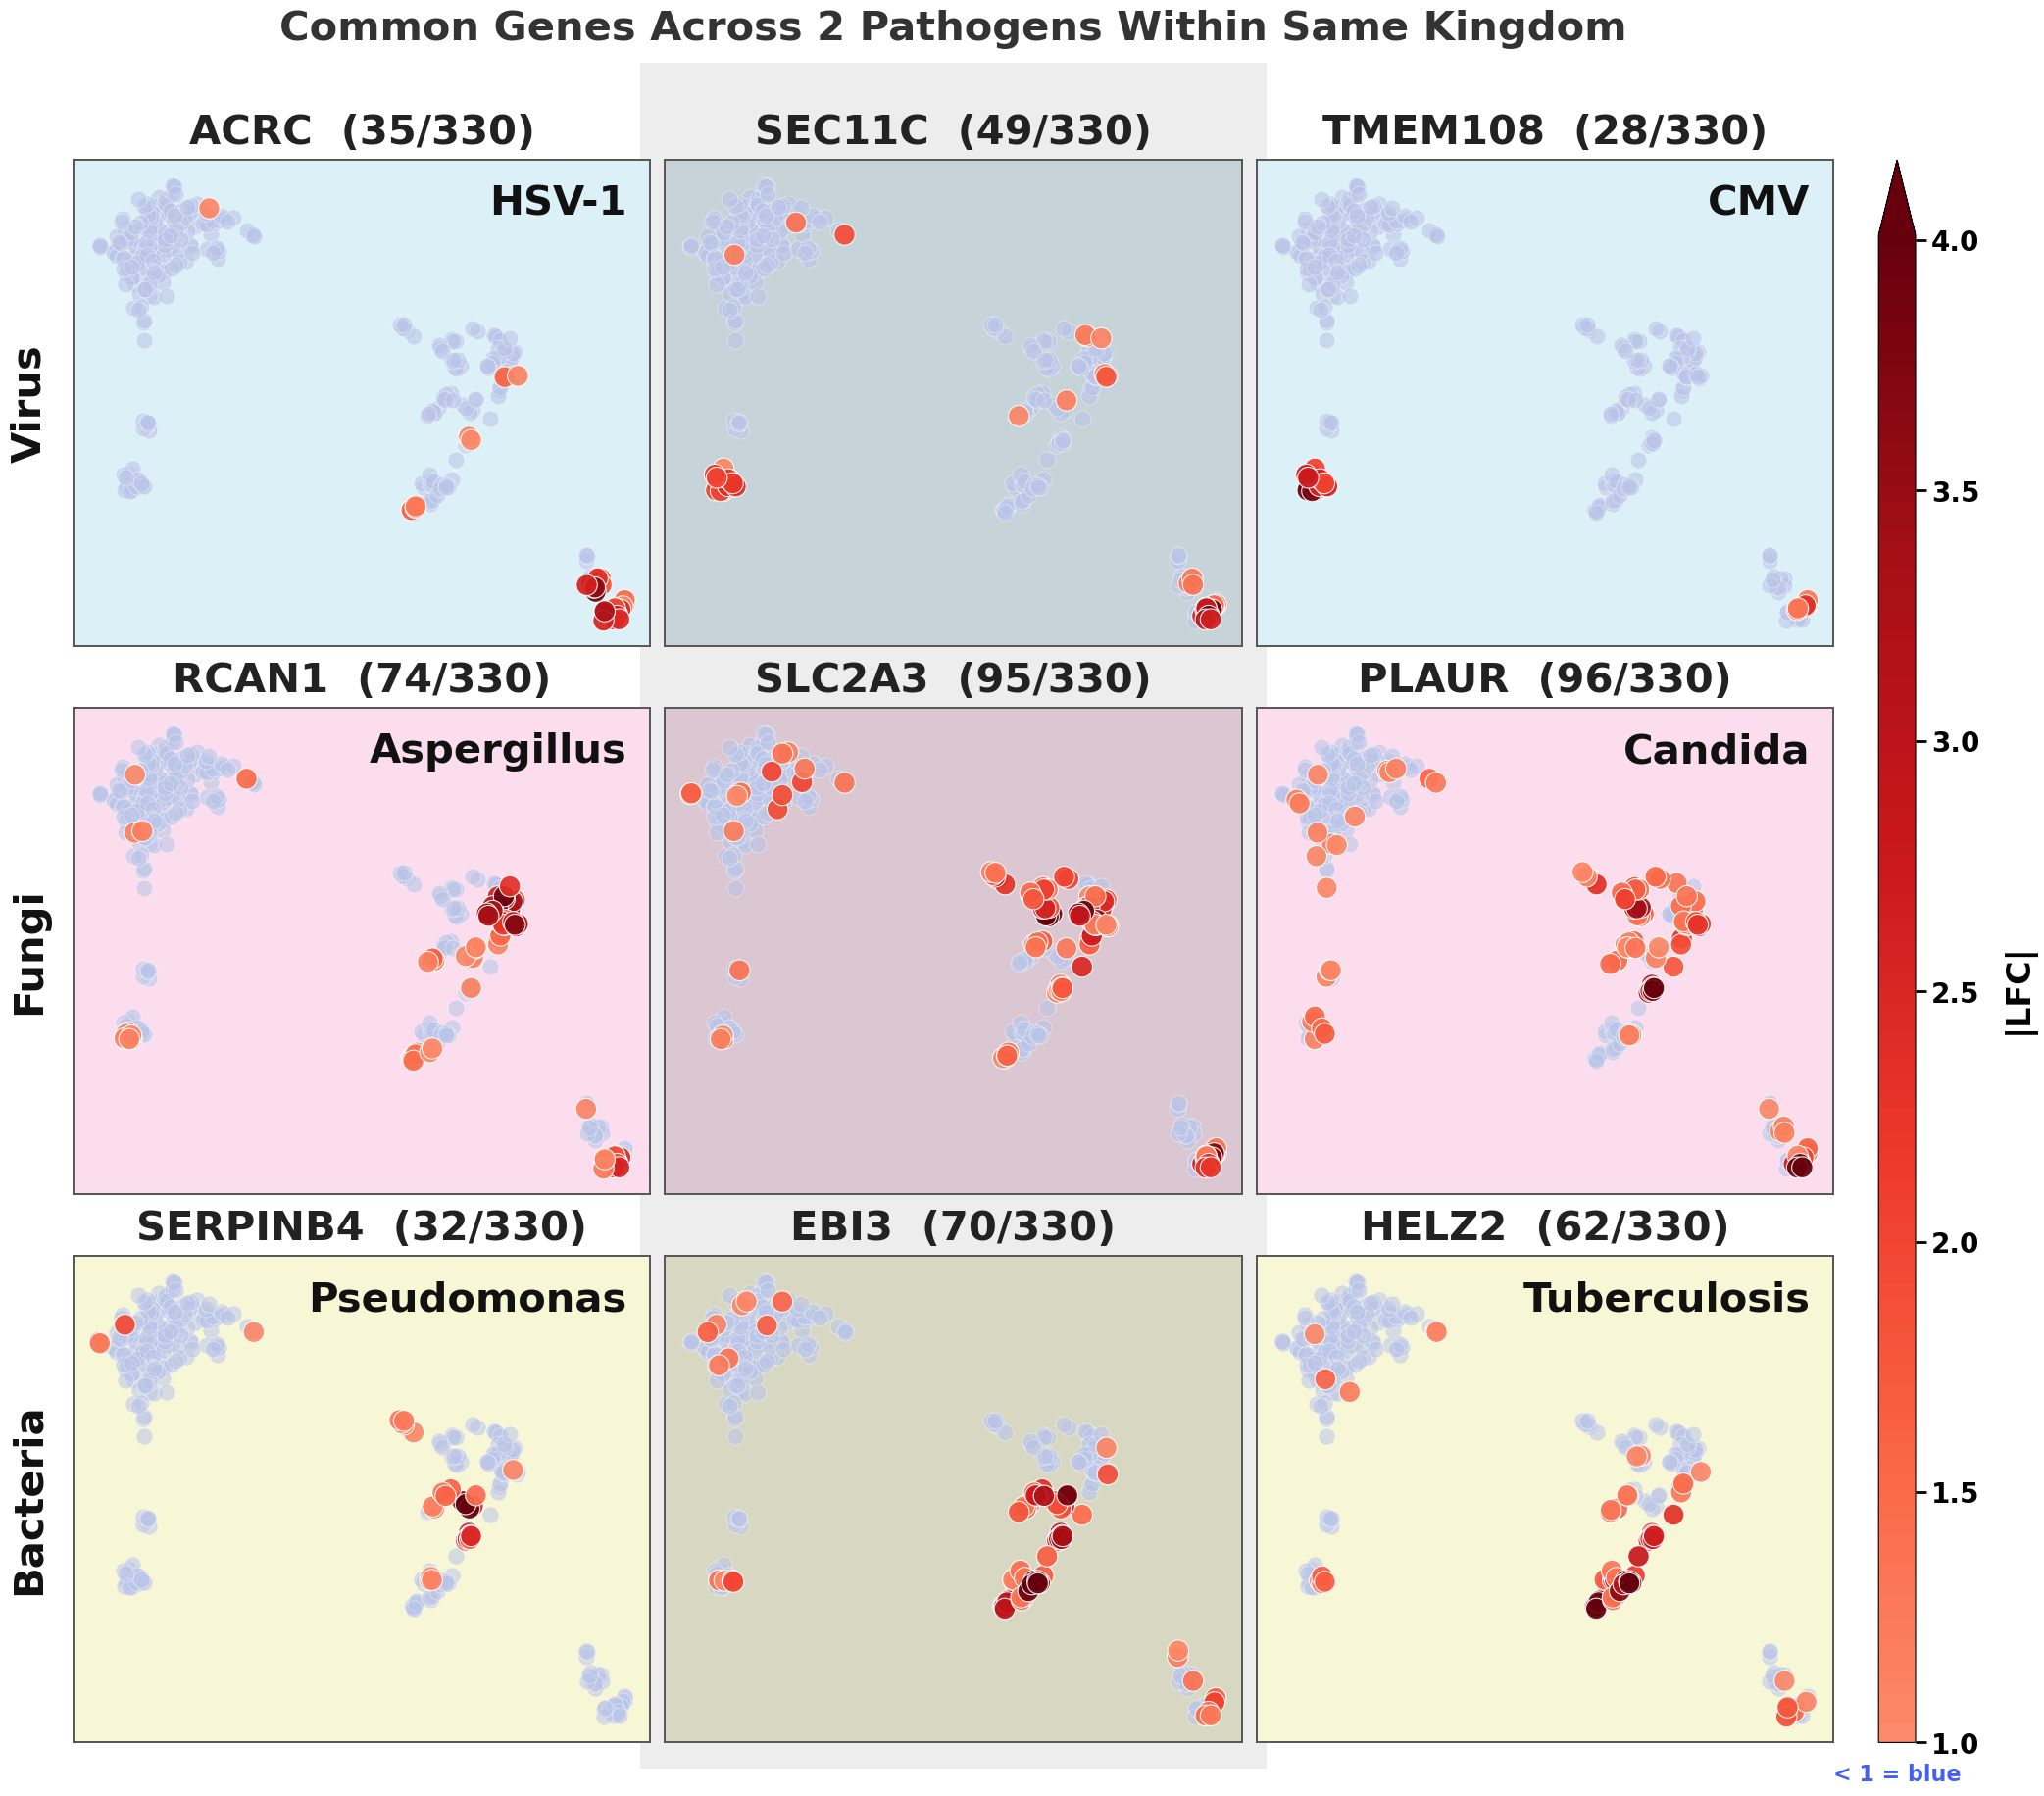

saved: C:\Users\mariaplumber\Downloads\umap_gene_panels_by_pathogen\UMAP_all_selected_genes


In [116]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.colors import to_rgb, ListedColormap, Normalize
from matplotlib.cm import ScalarMappable
OUT      = r'C:\Users\mariaplumber\Downloads\umap_gene_panels_by_pathogen\UMAP_all_selected_genes'
THRESH   = 1.0
CAP      = 4.01      # fixed so shades match earlier figures
GREY_MIX = 0.35      # how much grey to blend into the middle column

def mix(c, g='#9E9E9E', f=GREY_MIX):
    a, b = np.array(to_rgb(c)), np.array(to_rgb(g))
    return tuple((1 - f) * a + f * b)

layout = [
    ('Virus',    '#DCF0F7', [('ACRC', 'HSV-1'),           ('SEC11C', ''), ('TMEM108', 'CMV')]),
    ('Fungi',    '#FBDDEE', [('RCAN1', 'Aspergillus'),      ('SLC2A3', ''), ('PLAUR', 'Candida')]),
    ('Bacteria', '#F7F7D5', [('SERPINB4', 'Pseudomonas'), ('EBI3', ''),  ('HELZ2', 'Tuberculosis')]),
]
lookup  = {c.upper(): c for c in gene_cols}
wanted  = [g for _, _, row in layout for g, _ in row]
missing = [g for g in wanted if g.upper() not in lookup]
if missing:
    print(f"NOT IN MATRIX: {missing}")

coords = umap_df[['UMAP1', 'UMAP2']]
reds   = plt.get_cmap('Reds')

fig, axes = plt.subplots(3, 3, figsize=(21, 18))
xlim = (coords['UMAP1'].min() - 0.6, coords['UMAP1'].max() + 0.6)
ylim = (coords['UMAP2'].min() - 0.6, coords['UMAP2'].max() + 0.6)

for r, (kingdom, band_col, row) in enumerate(layout):
    for c, (gene, plabel) in enumerate(row):
        ax = axes[r, c]
        ax.set_facecolor(mix(band_col) if c == 1 else band_col)

        if gene.upper() not in lookup:
            ax.text(0.5, 0.5, f'{gene}\nnot in matrix', ha='center',
                    va='center', transform=ax.transAxes, fontsize=16)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        v   = lfc_df_with_mock[lookup[gene.upper()]].reindex(coords.index)
        hit = v.abs() >= THRESH

        ax.scatter(coords.loc[~hit, 'UMAP1'], coords.loc[~hit, 'UMAP2'],
                   c='#B9C4E8', s=150, alpha=0.55,
                   edgecolors='white', linewidths=0.5, zorder=1)

        if hit.any():
            t = ((v[hit].abs() - THRESH) / (CAP - THRESH)).clip(0, 1)
            ax.scatter(coords.loc[hit, 'UMAP1'], coords.loc[hit, 'UMAP2'],
                       c=reds(0.40 + 0.60 * t.values), s=240, alpha=0.92,
                       edgecolors='white', linewidths=0.8, zorder=3)

        ax.set_title(f'{gene}  ({hit.sum()}/{len(v)})',
                     fontsize=30, fontweight='bold', color='#222222', pad=12)

        if plabel:
            ax.text(0.96, 0.95, plabel, transform=ax.transAxes,
                    fontsize=30, fontweight='bold', va='top', ha='right',
                    color='#111111')

        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        for s in ax.spines.values():
            s.set_edgecolor('#555555'); s.set_linewidth(1.4)

    axes[r, 0].set_ylabel(kingdom, fontsize=30, fontweight='bold',
                          labelpad=18, color='#111111')

# leave room on the right for the colourbar
plt.tight_layout(rect=[0, 0, 0.90, 0.94])
fig.canvas.draw()

# ---- light band behind the middle column ----
b_top = axes[0, 1].get_position()
b_bot = axes[2, 1].get_position()
pad_x, pad_b, pad_t = 0.012, 0.015, 0.055

fig.patches.append(plt.Rectangle(
    (b_top.x0 - pad_x, b_bot.y0 - pad_b),
    (b_top.x1 - b_top.x0) + 2 * pad_x,
    (b_top.y1 - b_bot.y0) + pad_b + pad_t,
    transform=fig.transFigure, facecolor='#EDEDED',
    edgecolor='none', zorder=-10))

fig.text((b_top.x0 + b_top.x1) / 2, b_top.y1 + pad_t + 0.008,
         'Common Genes Across 2 Pathogens Within Same Kingdom', ha='center', va='bottom',
         fontsize=30, fontweight='bold', color='#333333')

# ---- colourbar matching the panel ramp ----
r_top = axes[0, 2].get_position()
r_bot = axes[2, 2].get_position()
cax = fig.add_axes([r_top.x1 + 0.022, r_bot.y0, 0.018, r_top.y1 - r_bot.y0])

ramp = ListedColormap(reds(np.linspace(0.40, 1.00, 256)))
cb = fig.colorbar(ScalarMappable(norm=Normalize(THRESH, CAP), cmap=ramp),
                  cax=cax, extend='max')

ticks = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
cb.set_ticks(ticks)
cb.set_ticklabels([f'{t:.1f}' for t in ticks])
cb.ax.tick_params(labelsize=20, width=2, length=8)
for l in cb.ax.get_yticklabels():
    l.set_fontweight('bold')
cb.set_label('|LFC|', fontsize=24, fontweight='bold', labelpad=16)

fig.text(cax.get_position().x0 + 0.009, r_bot.y0 - 0.022,
         f'< {THRESH:.0f} = blue', ha='center',
         fontsize=16, color='#4361EE', fontweight='bold')

fig.savefig(OUT, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved: {OUT}')

subset sizes: 330 227 140


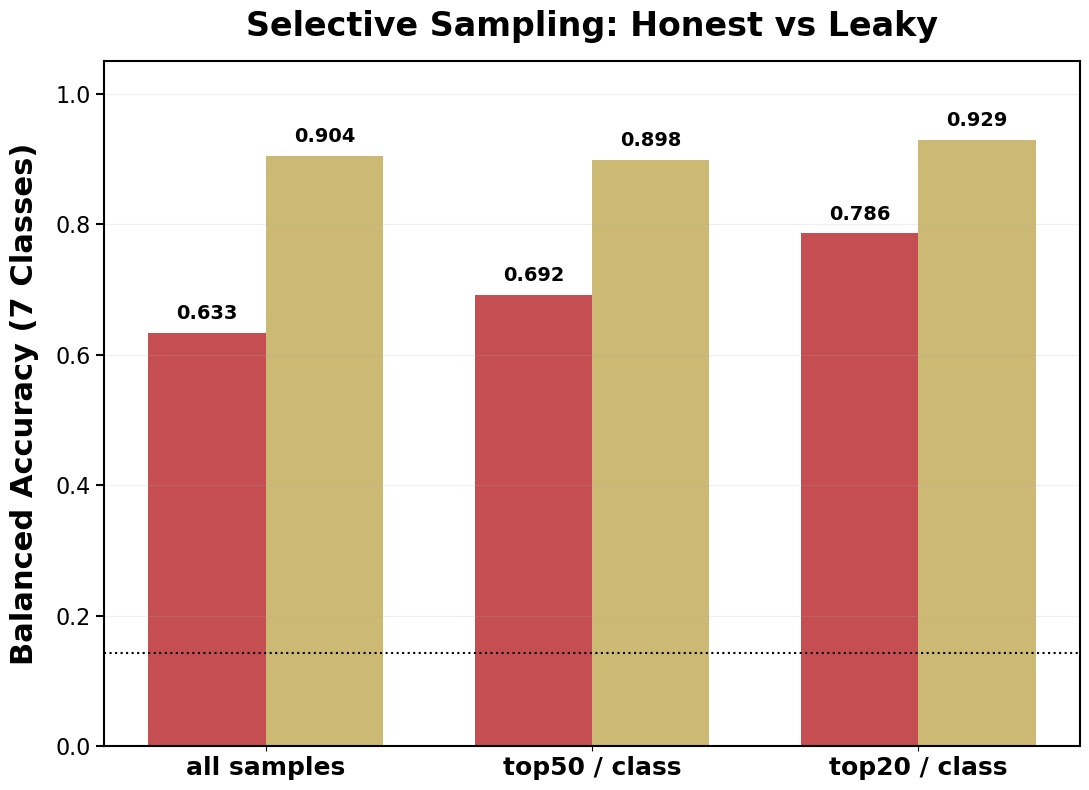

Table 6 (selective sampling):
       subset  balacc_LOSO_grouped  balacc_random
  all samples                0.633          0.904
top50 / class                0.692          0.898
top20 / class                0.786          0.929


In [112]:
def topk(k): return pd.concat([gp.sort_values('_mag', ascending=False).head(k) for _, gp in df.groupby('pathogen')])
def bacc7(sub, grouped):
    X = sub[GENES].astype(float).values; y = sub.pathogen.astype(str).values; g = sub.study.astype(str).values
    return round(balanced_accuracy_score(y, loso(X, y, g, rf, grouped, 60)), 3)

sel = pd.DataFrame([['all samples', bacc7(df,True), bacc7(df,False)],
                    ['top50 / class', bacc7(topk(50),True), bacc7(topk(50),False)],
                    ['top20 / class', bacc7(topk(20),True), bacc7(topk(20),False)]],
                   columns=['subset','balacc_LOSO_grouped','balacc_random'])

print("subset sizes:", len(df), len(topk(50)), len(topk(20)))
OUT = r'C:\Users\mariaplumber\Downloads\pipeline_outputs'
os.makedirs(OUT, exist_ok=True)

# ---- manuscript-quality plot ----
fig, ax = plt.subplots(figsize=(11, 8))
x = np.arange(len(sel)); w = 0.36

bars1 = ax.bar(x-w/2, sel.balacc_LOSO_grouped, w, label='Leave-one-study-out (honest)', color='#c44e52')
bars2 = ax.bar(x+w/2, sel.balacc_random, w, label='Random split (leaky)', color='#ccb974')

# value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.015, f'{height:.3f}',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.axhline(1/7, ls=':', c='k', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(sel.subset, fontsize=18, fontweight='bold')
ax.tick_params(axis='y', which='major', labelsize=16, width=1.5, length=6)

ax.set_ylabel("Balanced Accuracy (7 Classes)", fontsize=22, fontweight='bold', labelpad=12)
ax.set_ylim(0, 1.05)
ax.set_title("Selective Sampling: Honest vs Leaky", fontsize=24, fontweight='bold', pad=18)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(f"{OUT}/fig_selective_sampling_7class.png", dpi=300, bbox_inches='tight')
plt.show()

print("Table 6 (selective sampling):")
print(sel.to_string(index=False))

gene column: 'gene' | 142/142 present in matrix
matrix: 6 pathogens x 142 genes
colour cap: +/- 4.14


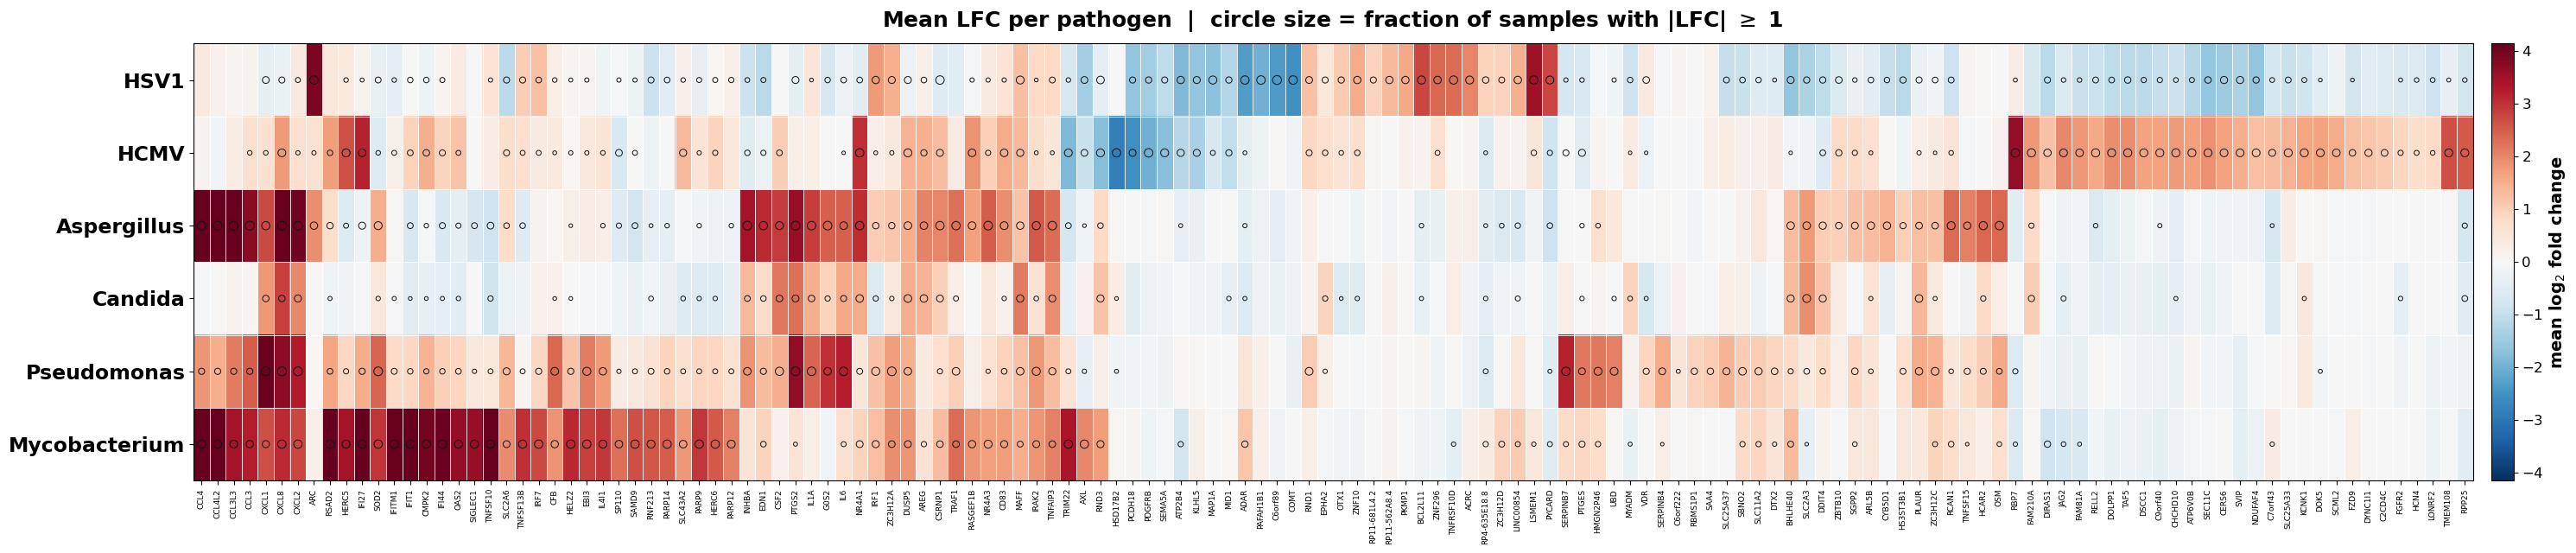

saved: C:\Users\mariaplumber\Downloads\heatmap_meanLFC_142genes.png


In [113]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

OUT    = r'C:\Users\mariaplumber\Downloads\heatmap_meanLFC_142genes.png'
SEL    = r'C:\Users\mariaplumber\Downloads\gene_selection_frequency_60_across_folds.csv'
THRESH = 1.0
SHOW_PREVALENCE = True    # circles sized by fraction of samples past THRESH
CLUSTER_COLS    = True

# ---- gene list ----
sel   = pd.read_csv(SEL)
gcol  = max(sel.columns, key=lambda c: len(set(sel[c].astype(str)) & set(gene_cols)))
genes = list(dict.fromkeys(g for g in sel[gcol].astype(str) if g in gene_cols))
print(f"gene column: '{gcol}' | {len(genes)}/{len(sel)} present in matrix")

# ---- infected samples only; Mock has no signature to summarise ----
lab  = lfc_df_with_mock['pathogen'].replace(
           {'Myctub': 'Mycobacterium', 'Pseuaer': 'Pseudomonas'})
keep = lab != 'Mock'
vals = lfc_df_with_mock.loc[keep, genes]
grp  = lab[keep]

row_order = ['HSV1', 'HCMV', 'Aspergillus', 'Candida',
             'Pseudomonas', 'Mycobacterium']
row_order = [p for p in row_order if p in set(grp)]

M  = vals.groupby(grp).mean().loc[row_order]                      # signed mean LFC
FR = (vals.abs() >= THRESH).groupby(grp).mean().loc[row_order]    # prevalence
print(f"matrix: {M.shape[0]} pathogens x {M.shape[1]} genes")

# ---- cluster genes so related columns sit together ----
if CLUSTER_COLS and M.shape[1] > 2:
    order = leaves_list(linkage(pdist(M.T.values), method='average'))
    M, FR = M.iloc[:, order], FR.iloc[:, order]

CAP = np.nanpercentile(np.abs(M.values), 99)
print(f"colour cap: +/- {CAP:.2f}")

fig, ax = plt.subplots(figsize=(30, 6.5))
im = ax.imshow(M.values, aspect='auto', cmap='RdBu_r', vmin=-CAP, vmax=CAP)

ax.set_xticks(range(M.shape[1]))
ax.set_xticklabels(M.columns, rotation=90, fontsize=6.5)
ax.set_yticks(range(M.shape[0]))
ax.set_yticklabels(M.index, fontsize=17, fontweight='bold')

if SHOW_PREVALENCE:
    yy, xx = np.meshgrid(range(M.shape[0]), range(M.shape[1]), indexing='ij')
    m = FR.values >= 0.15
    ax.scatter(xx[m], yy[m], s=(FR.values * 55)[m],
               facecolors='none', edgecolors='#111111', linewidths=0.7)

ax.set_xticks(np.arange(-.5, M.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, M.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.6)
ax.tick_params(which='minor', length=0)

cb = fig.colorbar(im, ax=ax, pad=0.008, fraction=0.02)
cb.set_label('mean log$_2$ fold change', fontsize=14, fontweight='bold')
cb.ax.tick_params(labelsize=12)

ax.set_title(
    f'Mean LFC per pathogen  |  circle size = fraction of samples with '
    f'|LFC| $\\geq$ {THRESH:.0f}',
    fontsize=18, fontweight='bold', pad=14)

plt.tight_layout()
fig.savefig(OUT, dpi=300, bbox_inches='tight')
plt.show()
print(f'saved: {OUT}')